In [1]:
# Initialization of packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import sklearn
import seaborn as sns
import statsmodels.api as sm
import glob
import os
import re


from xgboost import XGBClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from ModelingFunctions.GEMpythonlib.GEMpythonfunctions import *
from statsmodels.tsa.stattools import acf

from hmmlearn.hmm import GaussianHMM

In [2]:
# Define the columns and the prefixes you want to use
freq_a = 'Frequency 09B35150 (Hgr Walikale - Lab)'
freq_b = 'Frequency 64B734C2 (Hgr Walikale - Cabane)'
volt_a = 'Voltage 09B35150 (Hgr Walikale - Lab)'
volt_b = 'Voltage 64B734C2 (Hgr Walikale - Cabane)'


# Define the columns and the prefixes you want to use
columns_to_compare = [
    (freq_a, 'freq_lab'),
    (freq_b, 'freq_clinique'),
    (volt_a, 'volt_lab'),
    (volt_b, 'volt_clinique')
]


# Array or dataframe initialization
data = []

# Constant initialization
minutes_interval = 2

# Constants
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

# unit changes
kwh_to_hp_hr = 1.341
lb_to_gr = 453.592


# List of emissions
emissions = ['NOx', 'CO', 'SOx', 'CO2', 'PM']

# 1. Loading the Data

In [3]:
# Opening files
file_list = ['Voltage Time Series-data-2025-04-07 23_59_02.csv',
             'Voltage Time Series-data-2025-04-07 23_59_17.csv',
             'Voltage Time Series-data-2025-04-07 23_59_29.csv',
             'Voltage Time Series-data-2025-04-07 23_59_45.csv']

file_path = '../../data/1. Combination 1_Walikale/training/'

# Initialize an empty list to collect DataFrames
data_frames = []

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path + file)
    data_frames.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON
0,1/1/23 0:00,50.0,50.0,230.0,228.0,False
1,1/1/23 0:02,50.0,50.0,230.0,228.0,False
2,1/1/23 0:04,50.0,50.0,230.0,228.0,False
3,1/1/23 0:06,50.0,50.0,230.0,229.0,False
4,1/1/23 0:08,50.0,50.0,230.0,228.0,False
...,...,...,...,...,...,...
20155,1/28/23 23:50,50.0,NaN,230.0,NaN,False
20156,1/28/23 23:52,50.0,50.0,230.0,227.0,False
20157,1/28/23 23:54,50.0,NaN,230.0,NaN,False
20158,1/28/23 23:56,50.0,50.0,230.0,228.0,False


In [4]:
# Sort values by 'Time' in ascending order
data.sort_values('Time', ascending=True, inplace=True)

# Now you can proceed to drop the duplicates as before
data.drop_duplicates(subset='Time', inplace=True)

# Reset the index after dropping duplicates
data.reset_index(drop=True, inplace=True)

# Display the cleaned data
display(data)

,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON
0,1/1/23 0:00,50.0,50.0,230.0,228.0,False
1,1/1/23 0:02,50.0,50.0,230.0,228.0,False
2,1/1/23 0:04,50.0,50.0,230.0,228.0,False
3,1/1/23 0:06,50.0,50.0,230.0,229.0,False
4,1/1/23 0:08,50.0,50.0,230.0,228.0,False
...,...,...,...,...,...,...
20155,1/9/23 9:50,50.0,50.0,230.0,225.0,False
20156,1/9/23 9:52,50.0,50.0,230.0,225.0,False
20157,1/9/23 9:54,50.0,50.0,230.0,224.0,False
20158,1/9/23 9:56,50.0,50.0,230.0,224.0,False


In [5]:
# Checking if all rows have the same date time format:

data['Time'] = pd.to_datetime(data['Time'], format="%m/%d/%y %H:%M")
data['Time'].dtype

dtype('<M8[ns]')

In [6]:
# Check interval of data:

is_valid, invalid_data = check_time_intervals(data)

# If there are invalid rows, display them
if not is_valid:
    print("Invalid rows:")
    display(invalid_data)
    
#display(data.iloc[10078:10082])

Some rows are not separated by exactly 2 minutes.
Invalid rows:


,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON,time_diff
0,2023-01-01,50.0,50.0,230.0,228.0,False,NaT


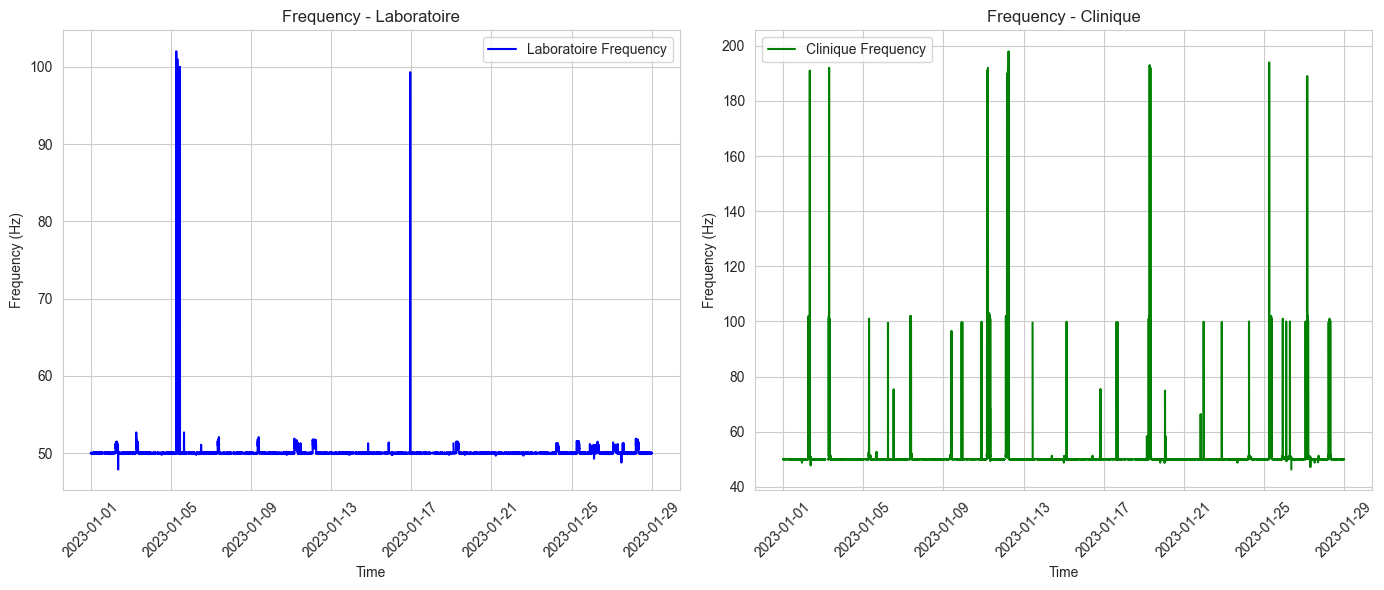

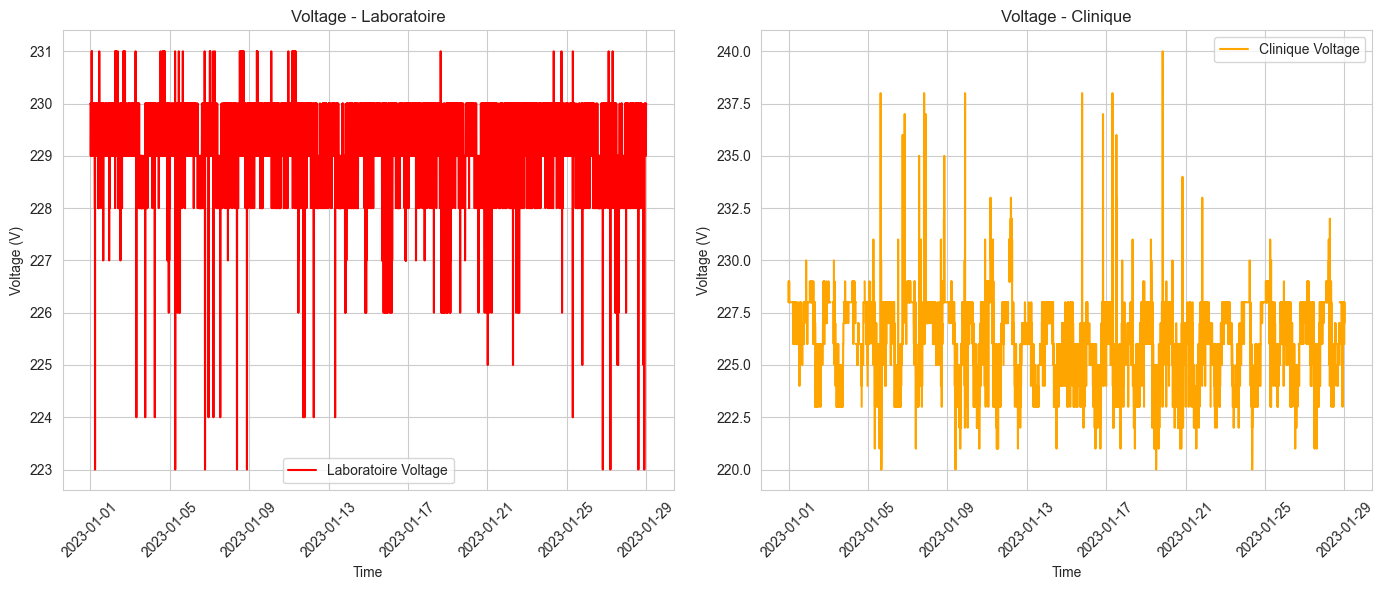

In [7]:
# Convert 'Time' column to datetime format
data['Time'] = pd.to_datetime(data['Time'])
data.sort_values('Time', ascending=True, inplace=True)

# Plot Frequency for both facilities
plt.figure(figsize=(14, 6))

# Plot Frequency for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data[freq_a], label='Laboratoire Frequency', color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Frequency for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data[freq_b], label='Clinique Frequency', color='green')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Plot Voltage for both facilities
plt.figure(figsize=(14, 6))

# Plot Voltage for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data[volt_a], label='Laboratoire Voltage', color='red')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Voltage for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data[volt_b], label='Clinique Voltage', color='orange')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# List of columns to calculate statistics
columns_of_interest = [
    freq_a,
    freq_b,
    volt_a,
    volt_b
]

# Calculate the statistics for each column, including mean, median, percentiles, and null counts
stats = data[columns_of_interest].agg([
    'mean',
    'median',
    lambda x: x.quantile(0.01),  # 1st percentile
    lambda x: x.quantile(0.99),  # 99th percentile
    lambda x: x.isnull().sum()/x.sum()*100  # Null counts
])

# Renaming the lambda output columns
stats.columns = columns_of_interest
stats.index = ['Mean', 'Median', '1st Percentile', '99th Percentile', 'Null Count (%)']

# Display the statistics
print(stats)

                 Frequency 09B35150 (Hgr Walikale - Lab)  \
Mean                                           50.077845   
Median                                         50.000000   
1st Percentile                                 49.900000   
99th Percentile                                51.300000   
Null Count (%)                                  0.004666   

                 Frequency 64B734C2 (Hgr Walikale - Cabane)  \
Mean                                              50.473549   
Median                                            50.000000   
1st Percentile                                    49.900000   
99th Percentile                                   51.600000   
Null Count (%)                                     0.093551   

                 Voltage 09B35150 (Hgr Walikale - Lab)  \
Mean                                        229.343261   
Median                                      229.000000   
1st Percentile                              227.000000   
99th Percentile             

# 2. Training and Test Data Separation

In [9]:
# Determine the split index (60% for training)
split_index = int(len(data) * 0.6)

# Split the data into training and testing sets
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

# Display the sizes of the train and test sets
print(f'Training data size: {len(train_data)}')
print(f'Test data size: {len(test_data)}')

# Optionally, display the first few rows of each
print("Training Data Sample:")
display(train_data)

print("Test Data Sample:")
display(test_data)

Training data size: 12096
Test data size: 8064
Training Data Sample:


,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON
0,2023-01-01 00:00:00,50.0,50.0,230.0,228.0,False
1,2023-01-01 00:02:00,50.0,50.0,230.0,228.0,False
2,2023-01-01 00:04:00,50.0,50.0,230.0,228.0,False
3,2023-01-01 00:06:00,50.0,50.0,230.0,229.0,False
4,2023-01-01 00:08:00,50.0,50.0,230.0,228.0,False
...,...,...,...,...,...,...
6061,2023-01-17 19:02:00,50.0,50.0,229.0,226.0,False
6062,2023-01-17 19:04:00,50.0,50.0,229.0,226.0,False
6063,2023-01-17 19:06:00,50.0,50.0,230.0,226.0,False
6064,2023-01-17 19:08:00,50.0,50.0,230.0,226.0,False


Test Data Sample:


,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON
6066,2023-01-17 19:12:00,50.0,50.0,229.0,226.0,False
6067,2023-01-17 19:14:00,50.0,50.0,229.0,226.0,False
6068,2023-01-17 19:16:00,50.0,50.0,230.0,230.0,False
6069,2023-01-17 19:18:00,50.0,50.1,230.0,228.0,False
6070,2023-01-17 19:20:00,50.0,50.0,230.0,226.0,False
...,...,...,...,...,...,...
14875,2023-01-28 23:50:00,50.0,NaN,230.0,NaN,False
14876,2023-01-28 23:52:00,50.0,50.0,230.0,227.0,False
14877,2023-01-28 23:54:00,50.0,NaN,230.0,NaN,False
14878,2023-01-28 23:56:00,50.0,50.0,230.0,228.0,False


# 3. Voltage and Frequency Only 

#### *3.1. Baseline Model on the Voltage and Frequency only*

-> Choosing only the most from the train set

In [10]:
train_data_base = train_data.copy()
test_data_base = test_data.copy()

In [11]:
train_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5
test_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5

display('Train data for baseline:')
display(train_data_base['prediction'])

display('Test data for baseline:')
display(test_data_base['prediction'])

'Train data for baseline:'

0       False
1       False
2       False
3       False
4       False
        ...  
6061    False
6062    False
6063    False
6064    False
6065    False
Name: prediction, Length: 12096, dtype: bool

'Test data for baseline:'

6066     False
6067     False
6068     False
6069     False
6070     False
         ...  
14875    False
14876    False
14877    False
14878    False
14879    False
Name: prediction, Length: 8064, dtype: bool

Assessing the model:

In [12]:
# TRAIN DATA EVALUATION
metrics = evaluate_model_performance(train_data_base)

Accuracy of model: 0.9514715608465608
Confusion Matrix:
[[11509     0]
 [  587     0]]
Precision of model: 0.0
Recall of model: 0.0


In [13]:
# TEST DATA EVALUATION
metrics = evaluate_model_performance(test_data_base)

Accuracy of model: 0.8990575396825397
Confusion Matrix:
[[7250    0]
 [ 814    0]]
Precision of model: 0.0
Recall of model: 0.0


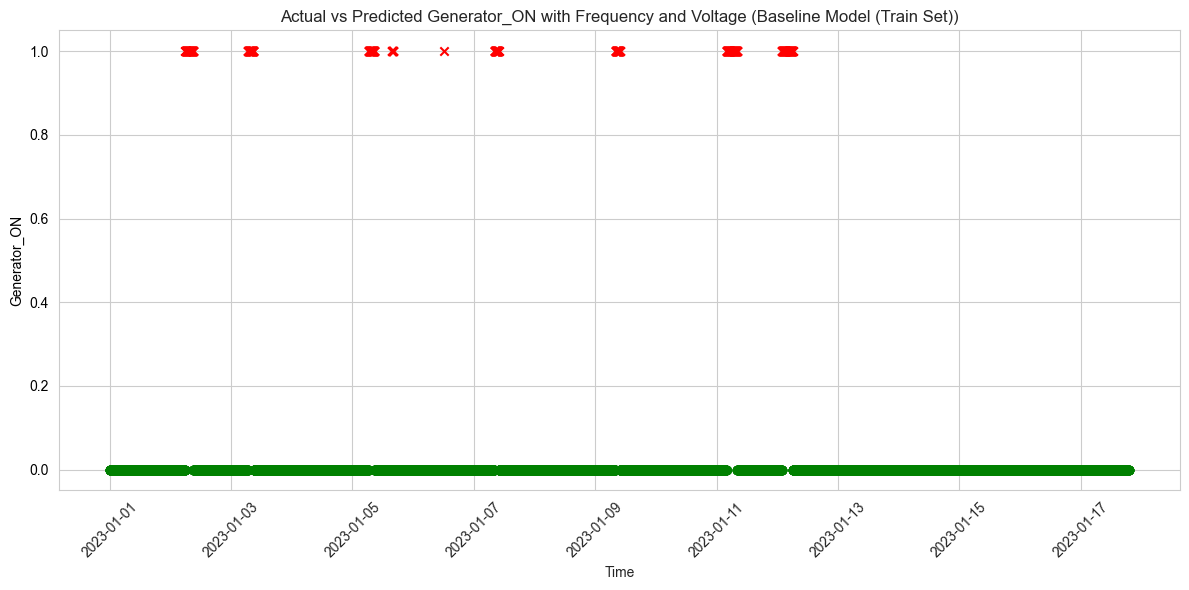

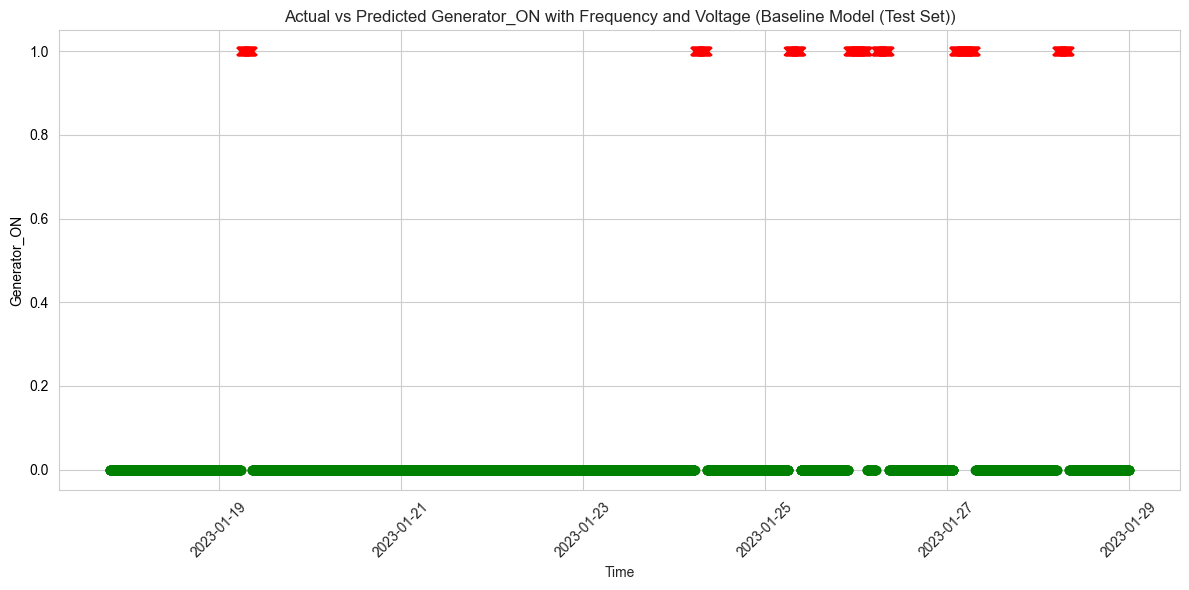

In [14]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)", 
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)",  
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

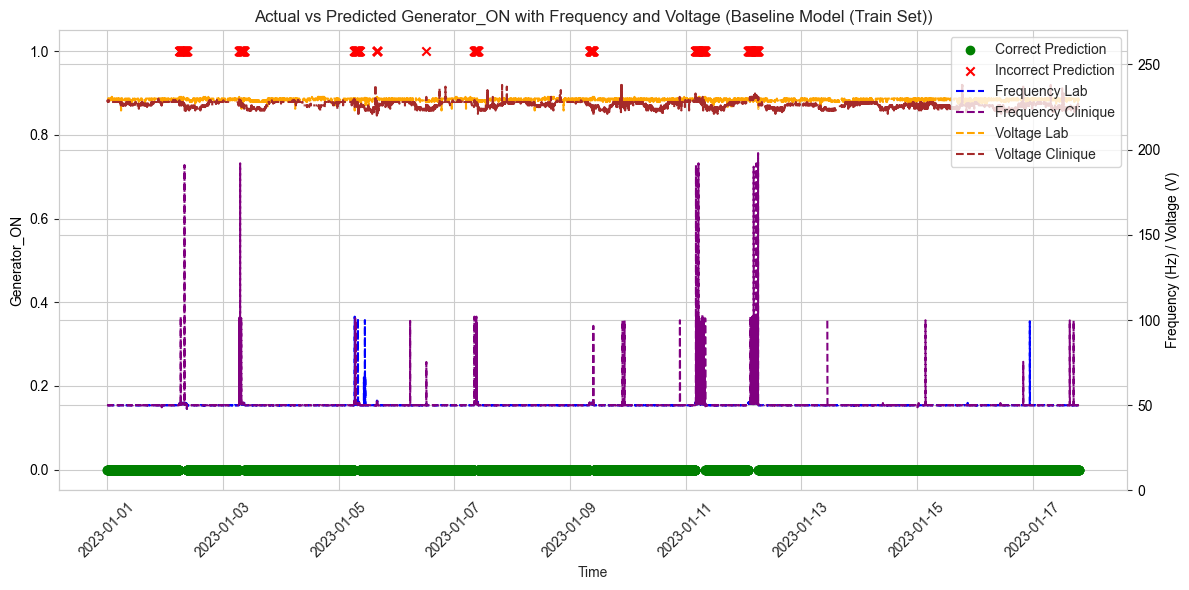

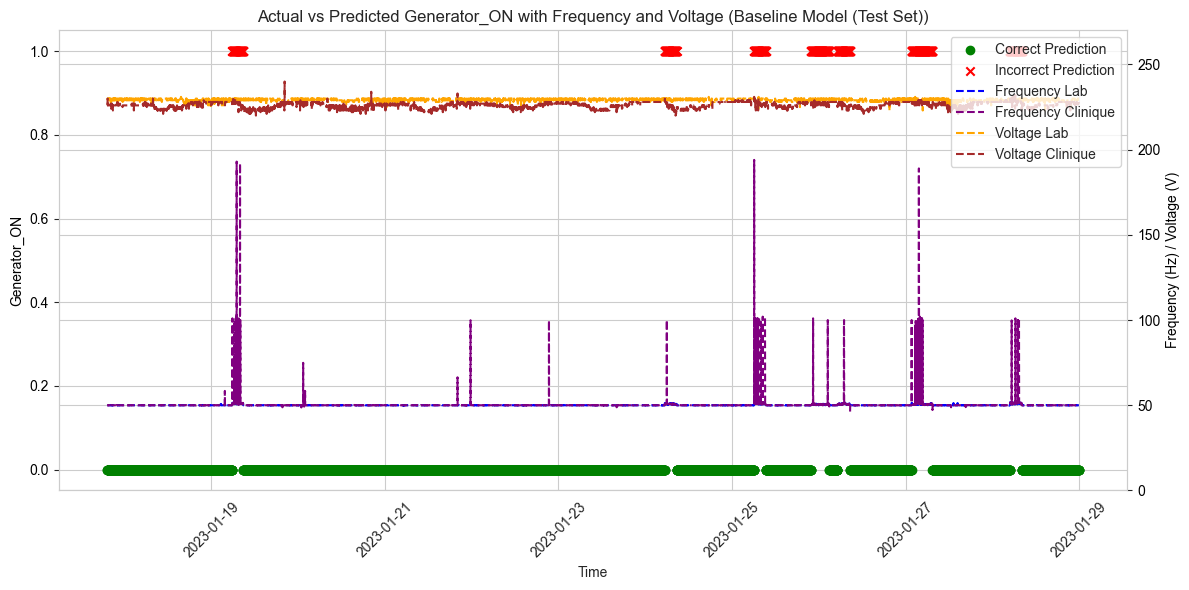

In [15]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)",  
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

#### *3.2. Logistic Regression on the Voltage and Frequency only*

In [16]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.96
Test Accuracy: 0.91


Evaluating the train set - Baseline Logistic Regression:

In [17]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9556051587301587
Confusion Matrix:
[[11497    12]
 [  525    62]]
Precision: 0.8378378378378378
Recall: 0.10562180579216354
Train data prediction distribution:
prediction
0    12022
1       74
Name: count, dtype: int64


Evaluating the test set - Baseline Logistic Regression:

In [18]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9064980158730159
Confusion Matrix:
[[7248    2]
 [ 752   62]]
Precision: 0.96875
Recall: 0.07616707616707617
Test data prediction distribution:
prediction
0    8000
1      64
Name: count, dtype: int64


#### *3.3. Random Forrest on the Voltage and Frequency only*

In [19]:
# Step 1: Create copies of the original data
train_data_rf = train_data.copy()
test_data_rf = test_data.copy()

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_rf[feature_columns]
y_train = train_data_rf['Generator_ON']

X_test = test_data_rf[feature_columns]
y_test = test_data_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_rf['prediction'] = clf.predict(X_train)
test_data_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [20]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.999917328042328
Confusion Matrix:
[[11509     0]
 [    1   586]]
Precision: 1.0
Recall: 0.9982964224872232
Train data prediction distribution:
prediction
False    11510
True       586
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [21]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9975198412698413
Confusion Matrix:
[[7250    0]
 [  20  794]]
Precision: 1.0
Recall: 0.9754299754299754
Test data prediction distribution:
prediction
False    7270
True      794
Name: count, dtype: int64


#### *3.4. XG-Boost on the Voltage and Frequency only*

Top 20 features sorted by importance (XGBoost):


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:16:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Feature,Importance
0,Frequency 09B35150 (Hgr Walikale - Lab),0.974753
1,Frequency 64B734C2 (Hgr Walikale - Cabane),0.017255
2,Voltage 09B35150 (Hgr Walikale - Lab),0.005369
3,Voltage 64B734C2 (Hgr Walikale - Cabane),0.002623


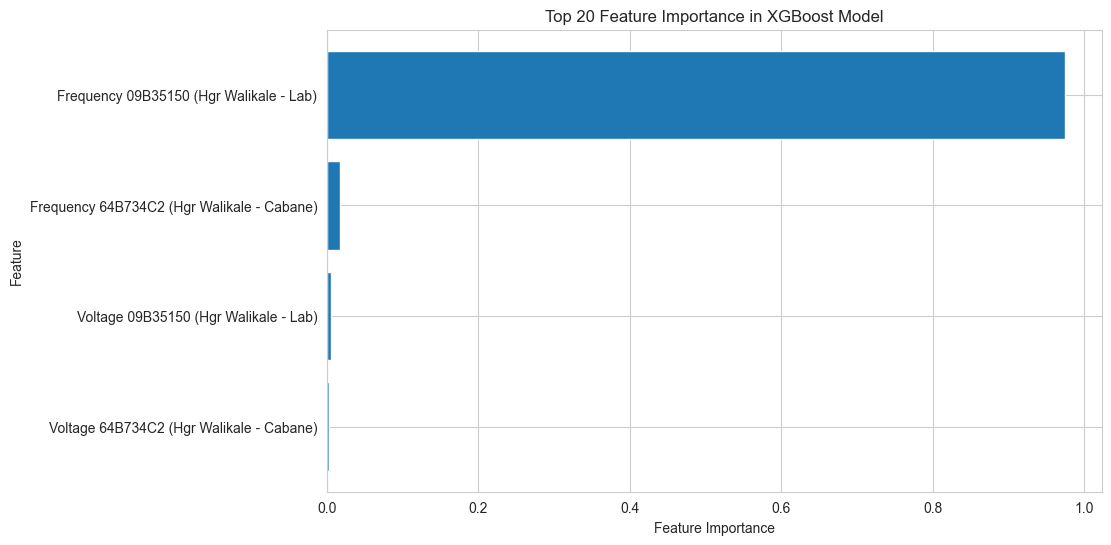

In [22]:
# Step 0: Copy rf data
train_data_boost = train_data.copy()
test_data_boost = test_data.copy()

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]


# Step 1: Use the same data and feature columns
X_train = train_data_boost[feature_columns]
y_train = train_data_boost['Generator_ON']

X_test = test_data_boost[feature_columns]
y_test = test_data_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_boost['prediction'] = xgb_clf.predict(X_train)
test_data_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [23]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9997519841269841
Confusion Matrix:
[[11509     0]
 [    3   584]]
Precision: 1.0
Recall: 0.9948892674616695
Train data prediction distribution (XGBoost):
prediction
0    11512
1      584
Name: count, dtype: int64


In [24]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9992559523809523
Confusion Matrix:
[[7250    0]
 [   6  808]]
Precision: 1.0
Recall: 0.9926289926289926
Test data prediction distribution (XGBoost):
prediction
0    11512
1      584
Name: count, dtype: int64


# 4. Feature Generation

### 4.1. Using Mean as a Threshold

In [25]:
train_data_mean = train_data.copy()
test_data_mean = test_data.copy()

In [26]:
# Taking the mean of the dataframe
train_data_mean, test_data_mean = calculate_mean_flags(train_data_mean, test_data_mean, train_data_base, columns_to_compare)

# Display the updated data
display(train_data_mean)
display(test_data_mean)

,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
0,2023-01-01 00:00:00,50.0,50.0,230.0,228.0,False,False,False,True,True
1,2023-01-01 00:02:00,50.0,50.0,230.0,228.0,False,False,False,True,True
2,2023-01-01 00:04:00,50.0,50.0,230.0,228.0,False,False,False,True,True
3,2023-01-01 00:06:00,50.0,50.0,230.0,229.0,False,False,False,True,True
4,2023-01-01 00:08:00,50.0,50.0,230.0,228.0,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
6061,2023-01-17 19:02:00,50.0,50.0,229.0,226.0,False,False,False,False,False
6062,2023-01-17 19:04:00,50.0,50.0,229.0,226.0,False,False,False,False,False
6063,2023-01-17 19:06:00,50.0,50.0,230.0,226.0,False,False,False,True,False
6064,2023-01-17 19:08:00,50.0,50.0,230.0,226.0,False,False,False,True,False


,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
6066,2023-01-17 19:12:00,50.0,50.0,229.0,226.0,False,False,False,False,False
6067,2023-01-17 19:14:00,50.0,50.0,229.0,226.0,False,False,False,False,False
6068,2023-01-17 19:16:00,50.0,50.0,230.0,230.0,False,False,False,True,True
6069,2023-01-17 19:18:00,50.0,50.1,230.0,228.0,False,False,False,True,True
6070,2023-01-17 19:20:00,50.0,50.0,230.0,226.0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...
14875,2023-01-28 23:50:00,50.0,NaN,230.0,NaN,False,False,False,True,False
14876,2023-01-28 23:52:00,50.0,50.0,230.0,227.0,False,False,False,True,True
14877,2023-01-28 23:54:00,50.0,NaN,230.0,NaN,False,False,False,True,False
14878,2023-01-28 23:56:00,50.0,50.0,230.0,228.0,False,False,False,True,True


#### 4.1.1. Using Mean as a Threshold - Custom Prediction

In [27]:
# Define custom prediction logic
def custom_prediction(row):
    # Example: Set prediction to True if either clinic or lab has higher frequency and voltage
    if (row['higher_freq_lab'] or row['higher_volt_lab']) and (row['higher_freq_clinique'] or row['higher_volt_clinique']):
        return True
    else:
        return False

# Apply custom prediction logic
train_data_mean['prediction'] = train_data_mean.apply(custom_prediction, axis=1)
test_data_mean['prediction'] = test_data_mean.apply(custom_prediction, axis=1)

# Show prediction:
display('Train data for baseline:')
display(train_data_mean['prediction'].value_counts())

display('Test data for baseline:')
display(test_data_mean['prediction'].value_counts())

'Train data for baseline:'

prediction
False    8233
True     3863
Name: count, dtype: int64

'Test data for baseline:'

prediction
False    6051
True     2013
Name: count, dtype: int64

Assessing the mean model: 

In [28]:
metrics = evaluate_model_performance(train_data_mean)

Accuracy of model: 0.7232142857142857
Confusion Matrix:
[[8197 3312]
 [  36  551]]
Precision of model: 0.14263525757183537
Recall of model: 0.938671209540034


In [29]:
metrics = evaluate_model_performance(test_data_mean)

Accuracy of model: 0.8230406746031746
Confusion Matrix:
[[5937 1313]
 [ 114  700]]
Precision of model: 0.34773969200198707
Recall of model: 0.85995085995086


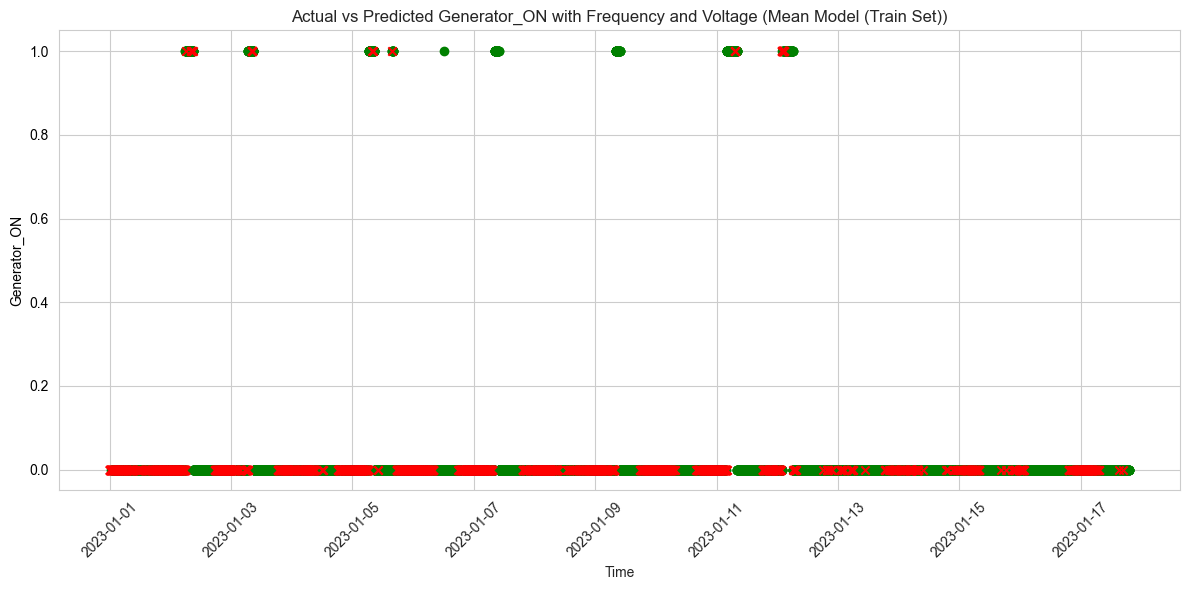

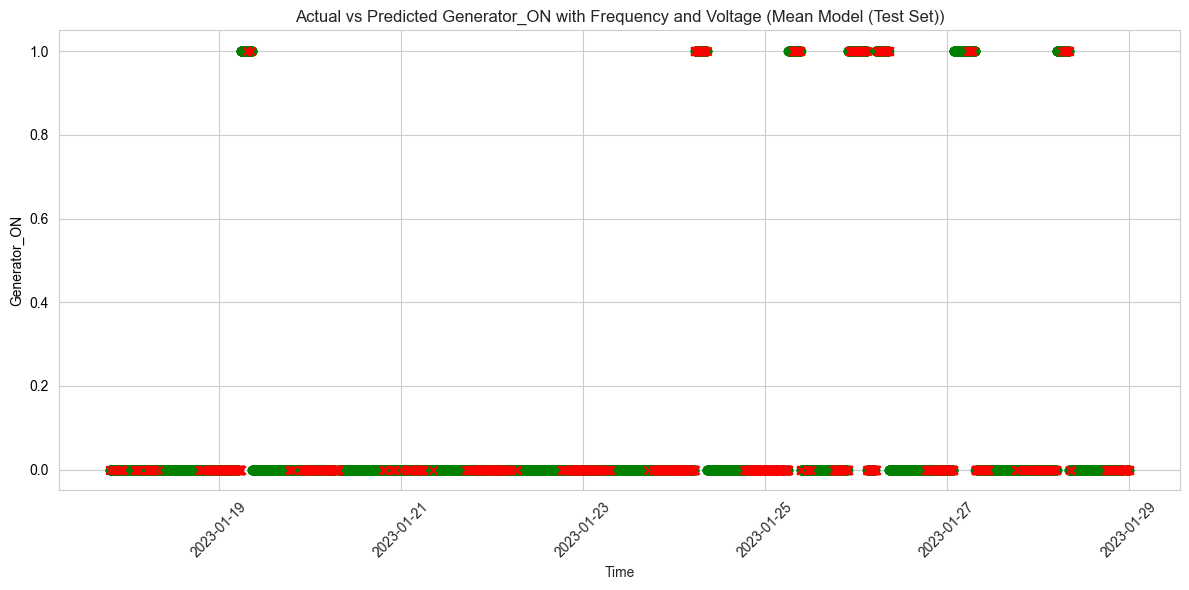

In [30]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

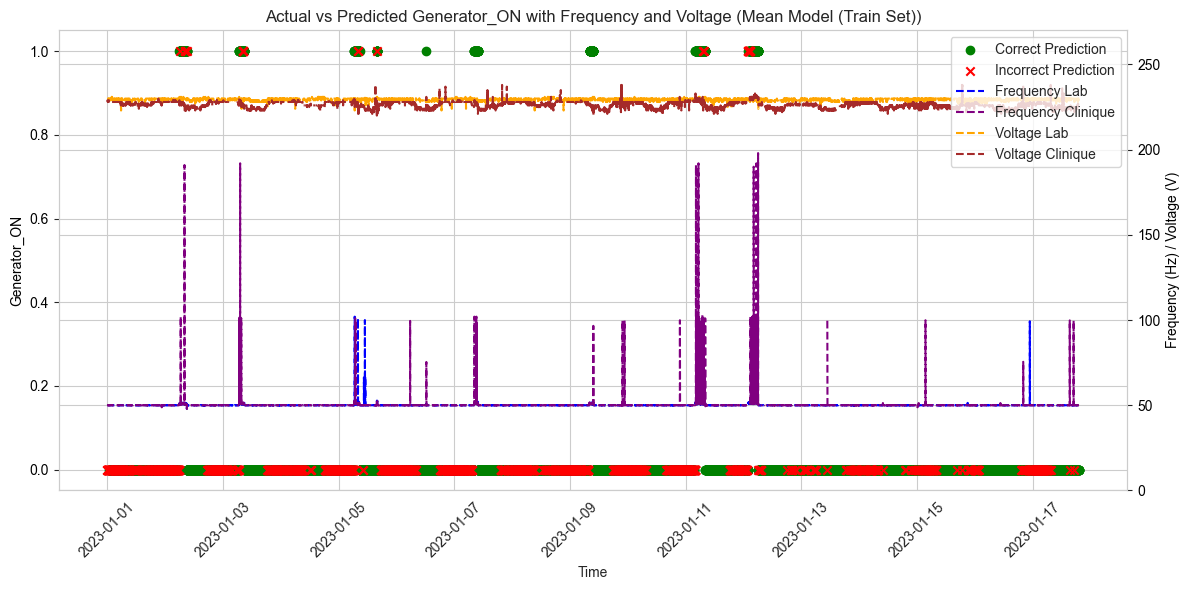

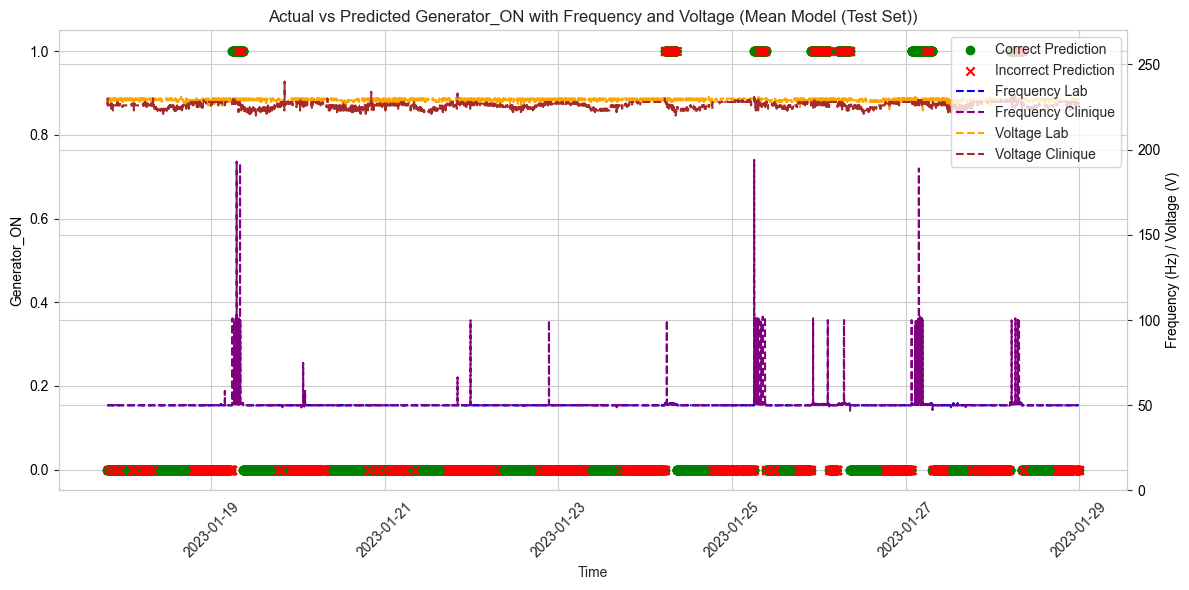

In [31]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

#### 4.1.2. Using Mean as a Threshold - Logistic Regression

In [32]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 1.00
Test Accuracy: 0.98


Evaluating the train set (Logistic Regression): 

In [33]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9955357142857143
Confusion Matrix:
[[11495    14]
 [   40   547]]
Precision: 0.9750445632798574
Recall: 0.9318568994889267
Train data prediction distribution:
prediction
0    11535
1      561
Name: count, dtype: int64


Evaluating the test set (Logistic Regression): 

In [34]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9763144841269841
Confusion Matrix:
[[7243    7]
 [ 184  630]]
Precision: 0.989010989010989
Recall: 0.773955773955774
Test data prediction distribution:
prediction
0    7427
1     637
Name: count, dtype: int64


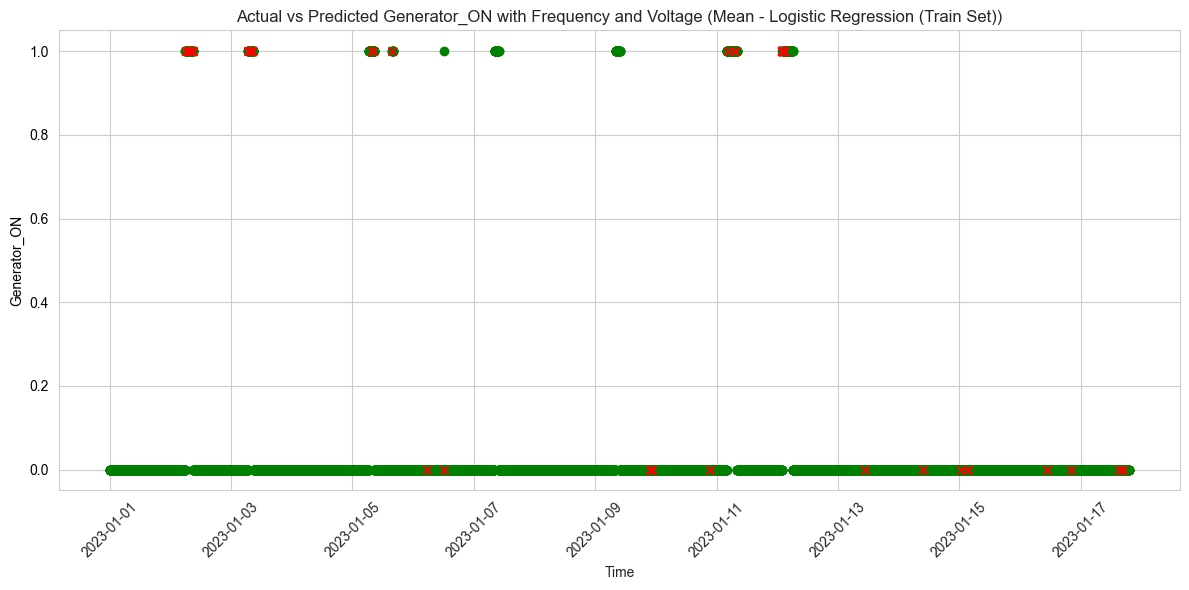

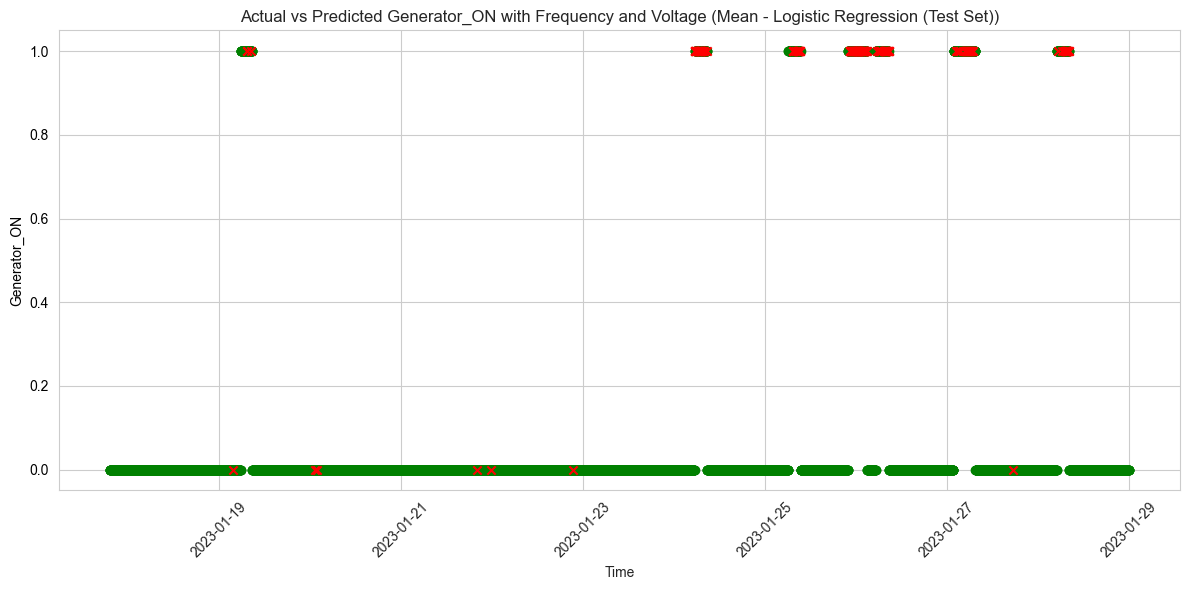

In [35]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

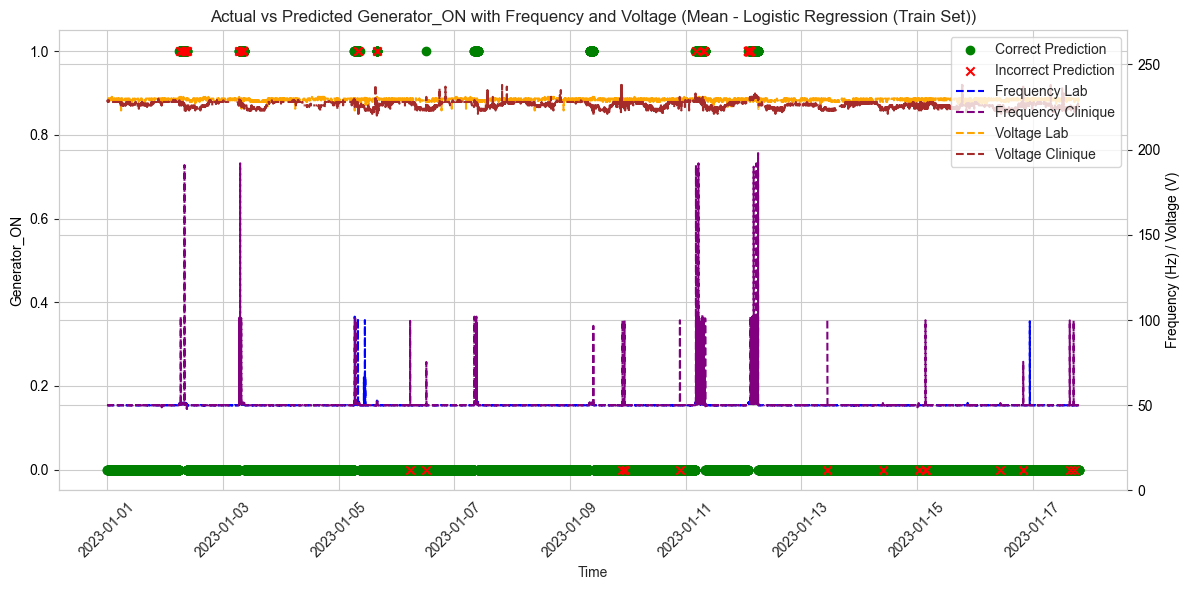

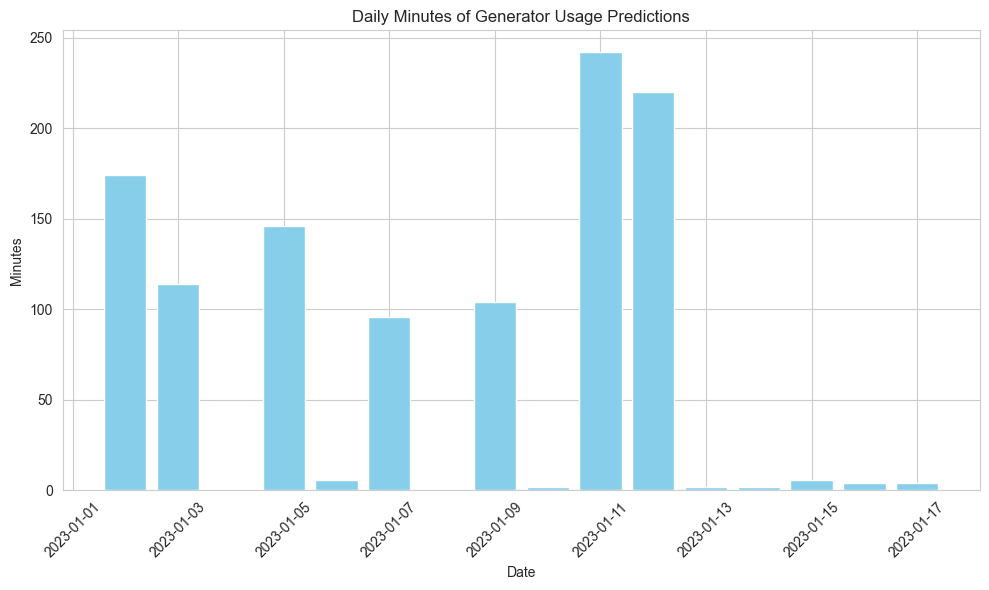

,Date,Count,Minutes,Hours
0,2023-01-02,87,174,2.900000
1,2023-01-03,57,114,1.900000
2,2023-01-05,73,146,2.433333
3,2023-01-06,3,6,0.100000
4,2023-01-07,48,96,1.600000
5,2023-01-09,52,104,1.733333
6,2023-01-10,1,2,0.033333
7,2023-01-11,121,242,4.033333
8,2023-01-12,110,220,3.666667
9,2023-01-13,1,2,0.033333


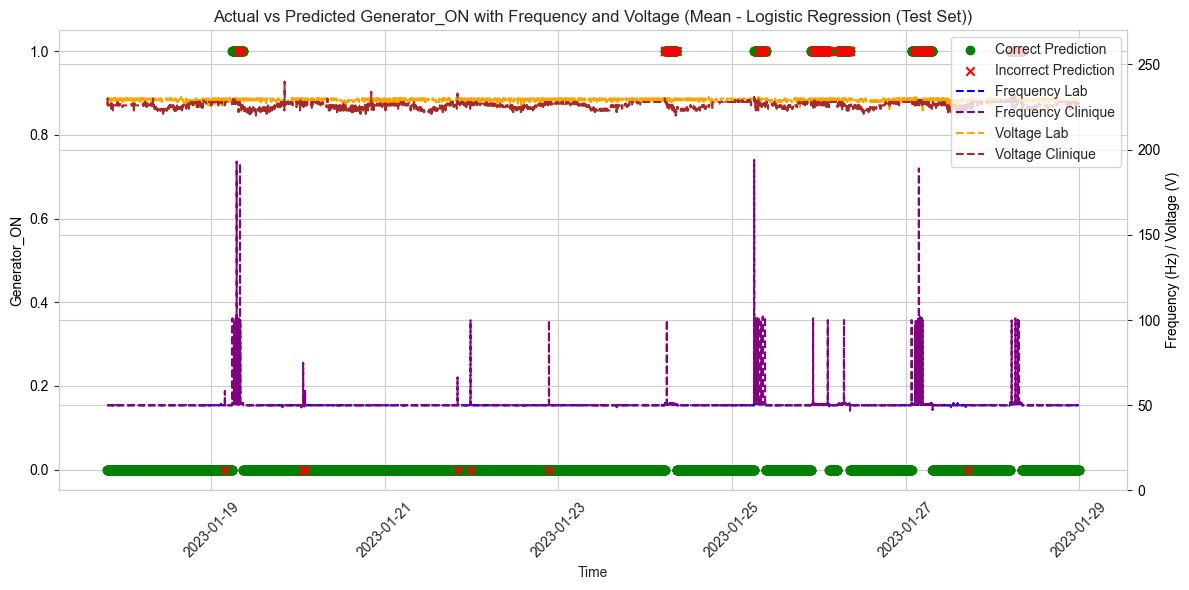

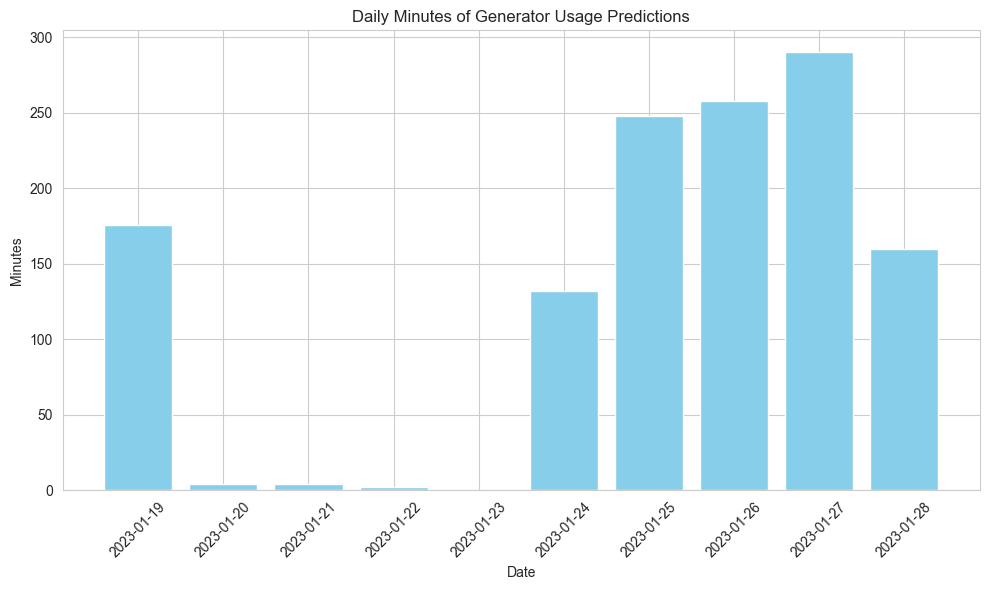

,Date,Count,Minutes,Hours
0,2023-01-19,88,176,2.933333
1,2023-01-20,2,4,0.066667
2,2023-01-21,2,4,0.066667
3,2023-01-22,1,2,0.033333
4,2023-01-24,66,132,2.200000
5,2023-01-25,124,248,4.133333
6,2023-01-26,129,258,4.300000
7,2023-01-27,145,290,4.833333
8,2023-01-28,80,160,2.666667


In [36]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_lg_daily_count = plot_true_predictions_histogram(train_data_mean_lg)
display(train_data_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_lg_daily_count = plot_true_predictions_histogram(test_data_mean_lg)
display(test_data_lg_daily_count)

#### 4.1.3. Using Mean as a Threshold - Random Forrest

In [37]:
# Step 1: Create copies of the original data
train_data_mean_rf = train_data.copy()
test_data_mean_rf = test_data.copy()

# Taking the mean of the dataframe
train_data_mean_rf, test_data_mean_rf = calculate_mean_flags(train_data_mean_rf, test_data_mean_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_rf[feature_columns]
y_train = train_data_mean_rf['Generator_ON']

X_test = test_data_mean_rf[feature_columns]
y_test = test_data_mean_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_rf['prediction'] = clf.predict(X_train)
test_data_mean_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [38]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.999917328042328
Confusion Matrix:
[[11509     0]
 [    1   586]]
Precision: 1.0
Recall: 0.9982964224872232
Train data prediction distribution:
prediction
False    11510
True       586
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [39]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9973958333333334
Confusion Matrix:
[[7249    1]
 [  20  794]]
Precision: 0.9987421383647799
Recall: 0.9754299754299754
Test data prediction distribution:
prediction
False    7269
True      795
Name: count, dtype: int64


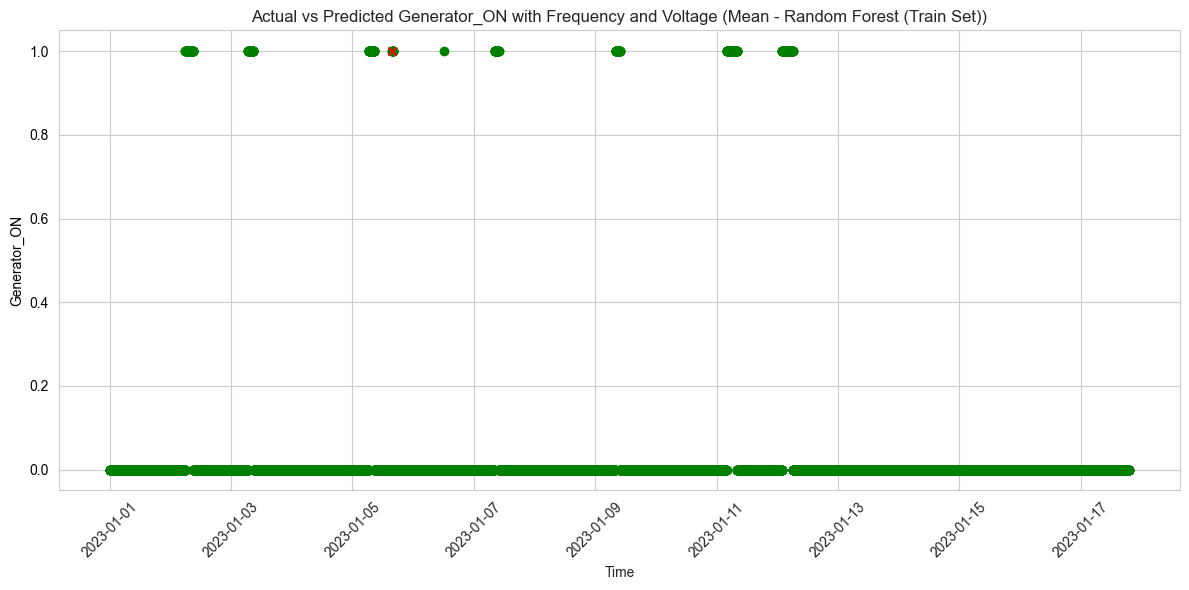

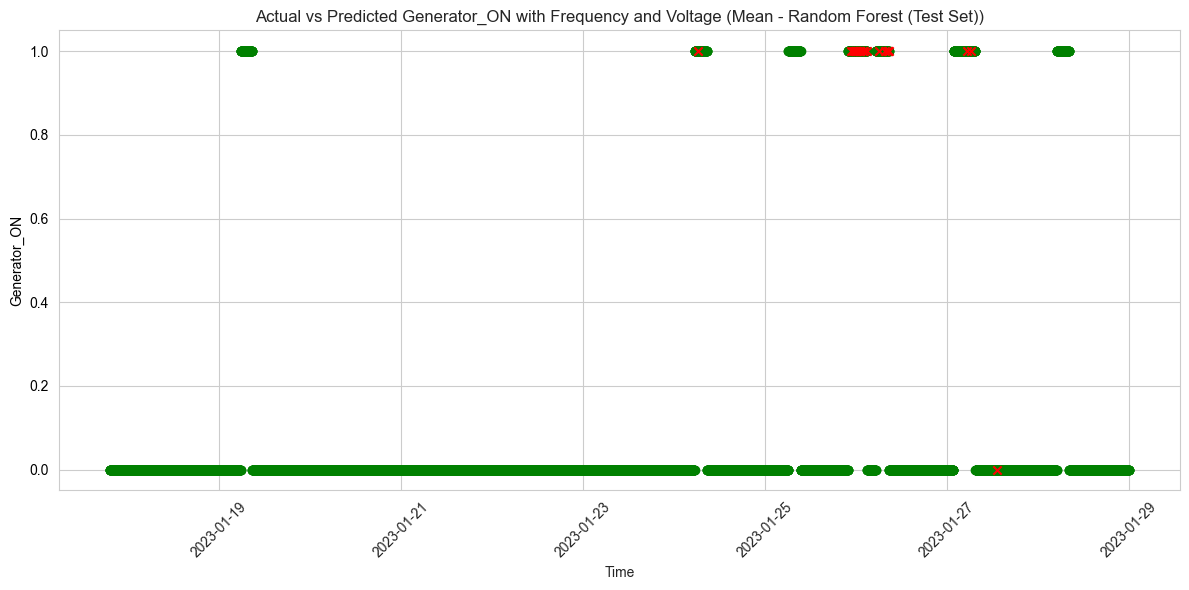

In [40]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

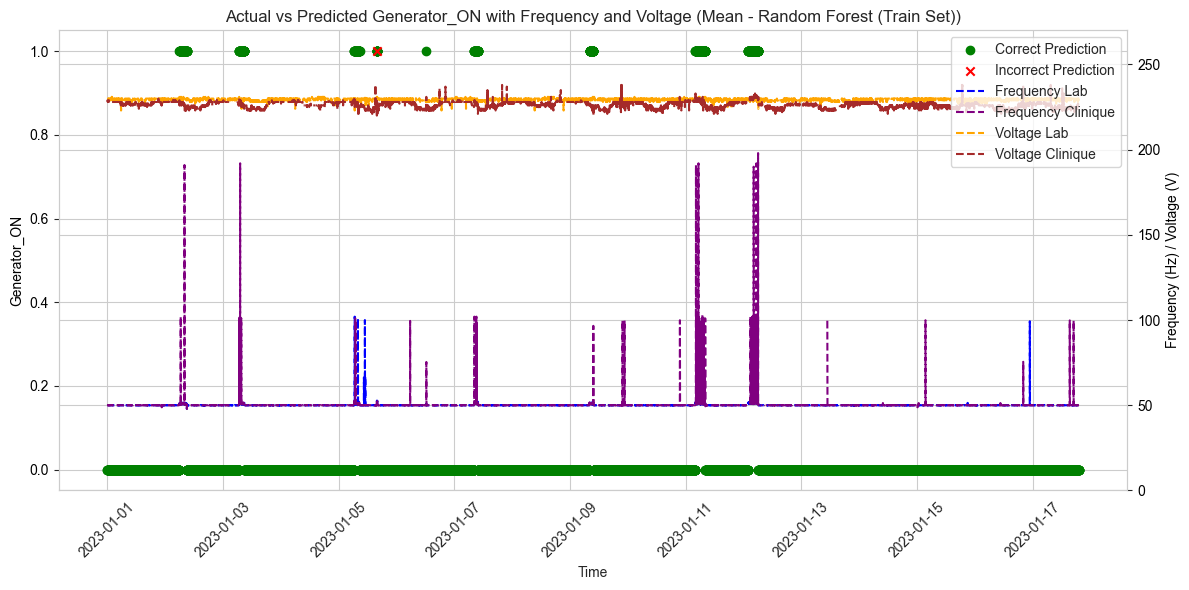

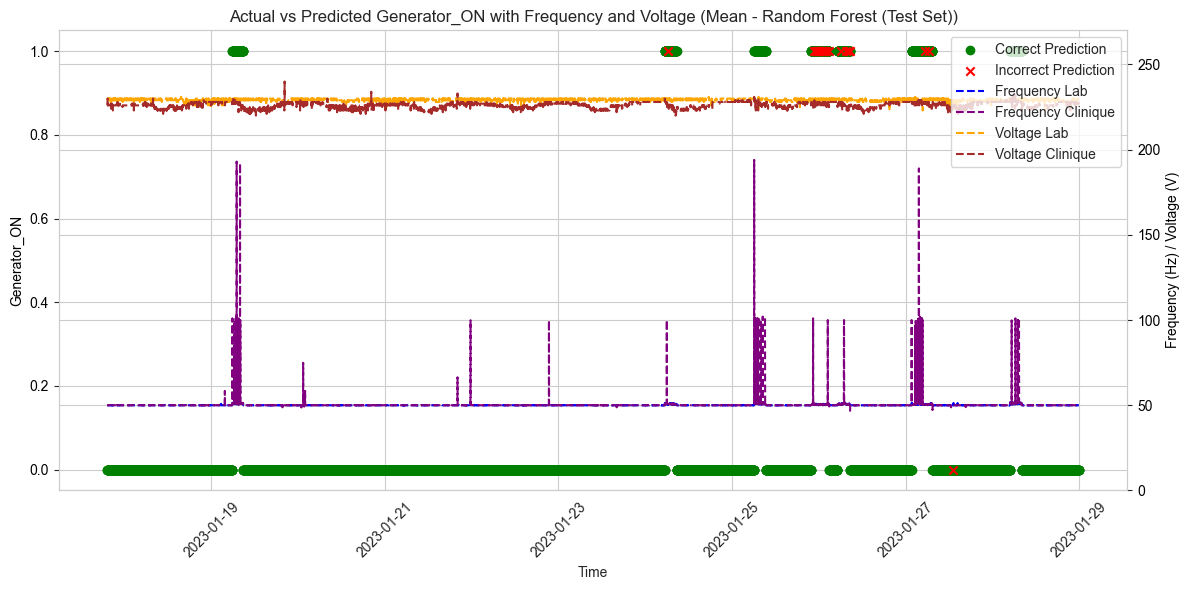

In [41]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

In [42]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_rf)
display_generator_statistics(test_data_mean_rf)

##### PREDICTION RESULT #####
Actual Minutes: 587 minutes, or 9.78 hours within 201.60 hours
Predicted Minutes: 586 minutes, or 9.77 hours within 201.60 hours
Actual Minutes: 814 minutes, or 13.57 hours within 134.40 hours
Predicted Minutes: 795 minutes, or 13.25 hours within 134.40 hours


#### 4.1.4. Using Mean as a Threshold - XGBoost

Top 20 features sorted by importance (XGBoost):


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:16:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Feature,Importance
0,Frequency 09B35150 (Hgr Walikale - Lab),0.974753
1,Frequency 64B734C2 (Hgr Walikale - Cabane),0.017255
2,Voltage 09B35150 (Hgr Walikale - Lab),0.005369
3,Voltage 64B734C2 (Hgr Walikale - Cabane),0.002623
4,higher_freq_lab,0.000000
5,higher_freq_clinique,0.000000
6,higher_volt_lab,0.000000
7,higher_volt_clinique,0.000000


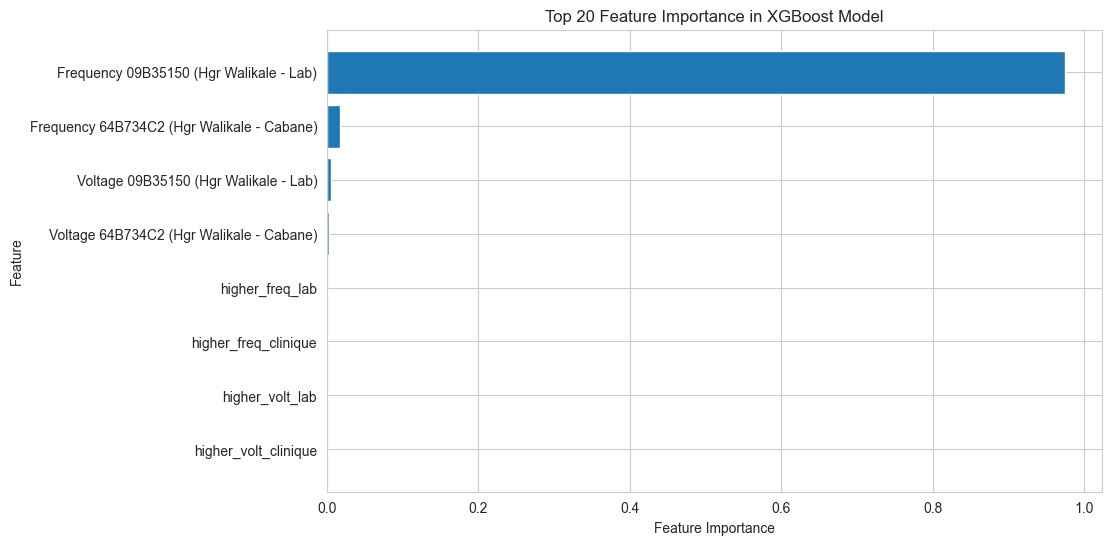

In [43]:
# Step 0: Copy rf data
train_data_mean_boost = train_data.copy()
test_data_mean_boost = test_data.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_mean_boost, test_data_mean_boost = calculate_mean_flags(train_data_mean_boost, test_data_mean_boost, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_mean_boost[feature_columns]
y_train = train_data_mean_boost['Generator_ON']

X_test = test_data_mean_boost[feature_columns]
y_test = test_data_mean_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_boost['prediction'] = xgb_clf.predict(X_train)
test_data_mean_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [44]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_mean_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9997519841269841
Confusion Matrix:
[[11509     0]
 [    3   584]]
Precision: 1.0
Recall: 0.9948892674616695
Train data prediction distribution (XGBoost):
prediction
0    11512
1      584
Name: count, dtype: int64


In [45]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_mean_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9992559523809523
Confusion Matrix:
[[7250    0]
 [   6  808]]
Precision: 1.0
Recall: 0.9926289926289926
Test data prediction distribution (XGBoost):
prediction
0    11512
1      584
Name: count, dtype: int64


In [46]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_boost)
display_generator_statistics(test_data_mean_boost)

##### PREDICTION RESULT #####
Actual Minutes: 587 minutes, or 9.78 hours within 201.60 hours
Predicted Minutes: 584 minutes, or 9.73 hours within 201.60 hours
Actual Minutes: 814 minutes, or 13.57 hours within 134.40 hours
Predicted Minutes: 808 minutes, or 13.47 hours within 134.40 hours


### 4.2. Generating Time Series Feature

In [47]:
## INITIALIZATION OF CONSTANTS
# Range of reasonable frequency and voltage
high_freq_threshold = 60
low_freq_threshold = 40

high_volt_threshold = 250
low_volt_threshold = 2

voltage_delta = 10

In [48]:
train_data_ts = train_data.copy()
test_data_ts = test_data.copy()

In [49]:
## FEATURE GENERATION
# Using mean to compare
train_data_ts, test_data_ts = calculate_mean_flags(train_data_ts, test_data_ts, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
train_data_ts, test_data_ts = process_time_series_data(train_data_ts, test_data_ts, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display the processed data
display(train_data_ts)
display(test_data_ts)

,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2023-01-01 00:00:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2023-01-01 00:02:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,2023-01-01 00:04:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,2023-01-01 00:06:00,50.0,50.0,230.0,229.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,2023-01-01 00:08:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6061,2023-01-17 19:02:00,50.0,50.0,229.0,226.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6062,2023-01-17 19:04:00,50.0,50.0,229.0,226.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6063,2023-01-17 19:06:00,50.0,50.0,230.0,226.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
6064,2023-01-17 19:08:00,50.0,50.0,230.0,226.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
6066,2023-01-17 19:12:00,50.0,50.0,229.0,226.0,False,False,False,False,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
6067,2023-01-17 19:14:00,50.0,50.0,229.0,226.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6068,2023-01-17 19:16:00,50.0,50.0,230.0,230.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
6069,2023-01-17 19:18:00,50.0,50.1,230.0,228.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
6070,2023-01-17 19:20:00,50.0,50.0,230.0,226.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14875,2023-01-28 23:50:00,50.0,NaN,230.0,NaN,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
14876,2023-01-28 23:52:00,50.0,50.0,230.0,227.0,False,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False
14877,2023-01-28 23:54:00,50.0,NaN,230.0,NaN,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
14878,2023-01-28 23:56:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False


In [50]:
train_data_ts.columns

Index(['Time', 'Frequency 09B35150 (Hgr Walikale - Lab)',
       'Frequency 64B734C2 (Hgr Walikale - Cabane)',
       'Voltage 09B35150 (Hgr Walikale - Lab)',
       'Voltage 64B734C2 (Hgr Walikale - Cabane)', 'Generator_ON',
       'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
       'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
       'freq_delta_negative_clinique', 'volt_delta_positive_lab',
       'volt_delta_positive_clinique', 'freq_in_range_lab',
       'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
       'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
       'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
       'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
       'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
       'High_delta_freq_lab', 'High_delta_freq_clinique',
       'High

#### 4.2.1. Using Mean of Voltage and Frequency as a Threshold and Time Series - Logistic Regression

Train Accuracy: 1.00
Test Accuracy: 0.98
Top 20 features sorted by absolute coefficient value:


,Feature,Coefficient
5,higher_freq_clinique,6.502119
4,higher_freq_lab,4.624804
12,freq_delta_negative_lab,2.082066
13,freq_delta_negative_clinique,2.045418
28,Hour_8,1.971397
22,Hour_2,1.746759
27,Hour_7,1.669814
19,volt_in_range_clinique,-1.111466
26,Hour_6,1.048828
30,Hour_10,-0.967956


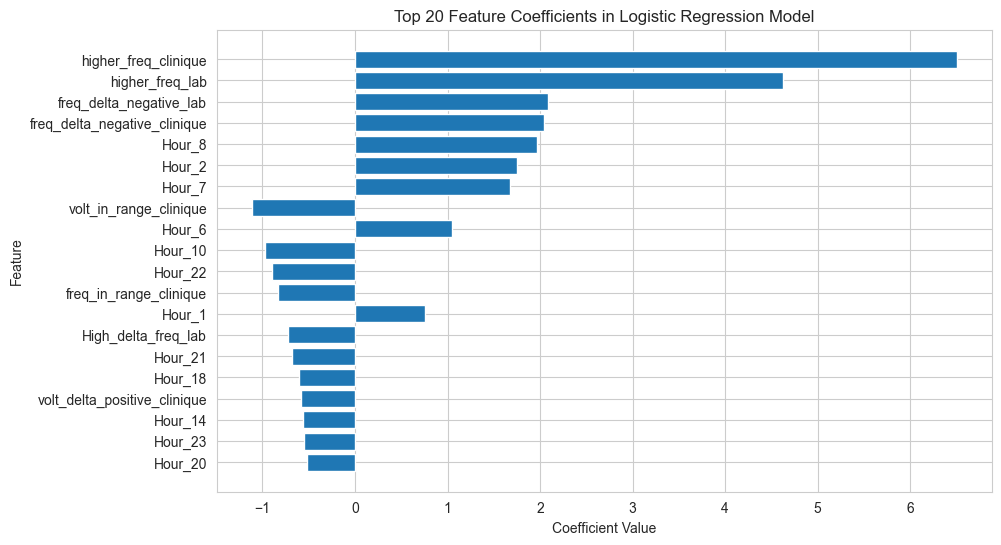

In [51]:

# Step 1: Create copies of the original data
train_data_ts_lg = train_data_ts.copy()
test_data_ts_lg = test_data_ts.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_lg, test_data_ts_lg = calculate_mean_flags(train_data_ts_lg, test_data_ts_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_lg[feature_columns]
y_train = train_data_ts_lg['Generator_ON']

X_test = test_data_ts_lg[feature_columns]
y_test = test_data_ts_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_lg['prediction'] = clf.predict(X_train)
test_data_ts_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

In [52]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.997933201058201
Confusion Matrix:
[[11507     2]
 [   23   564]]
Precision: 0.9964664310954063
Recall: 0.9608177172061328
Train data prediction distribution:
prediction
False    11530
True       566
Name: count, dtype: int64


In [53]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9841269841269841
Confusion Matrix:
[[7249    1]
 [ 127  687]]
Precision: 0.998546511627907
Recall: 0.8439803439803439
Test data prediction distribution:
prediction
False    7376
True      688
Name: count, dtype: int64


In [54]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_lg)
display_generator_statistics(test_data_ts_lg)

##### PREDICTION RESULT #####
Actual Minutes: 587 minutes, or 9.78 hours within 201.60 hours
Predicted Minutes: 566 minutes, or 9.43 hours within 201.60 hours
Actual Minutes: 814 minutes, or 13.57 hours within 134.40 hours
Predicted Minutes: 688 minutes, or 11.47 hours within 134.40 hours


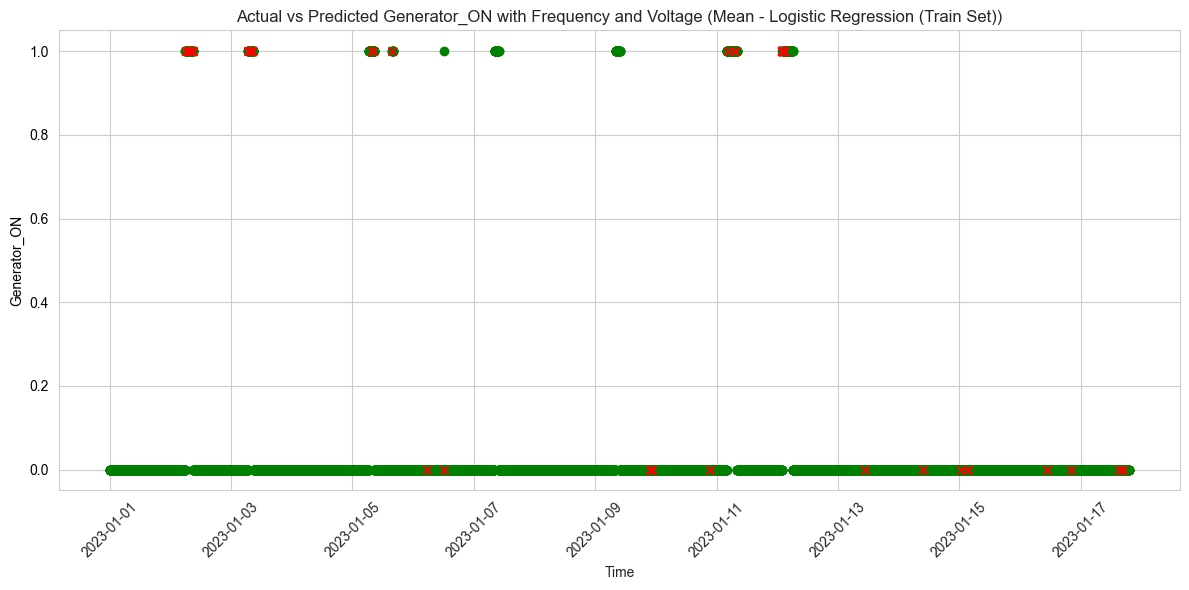

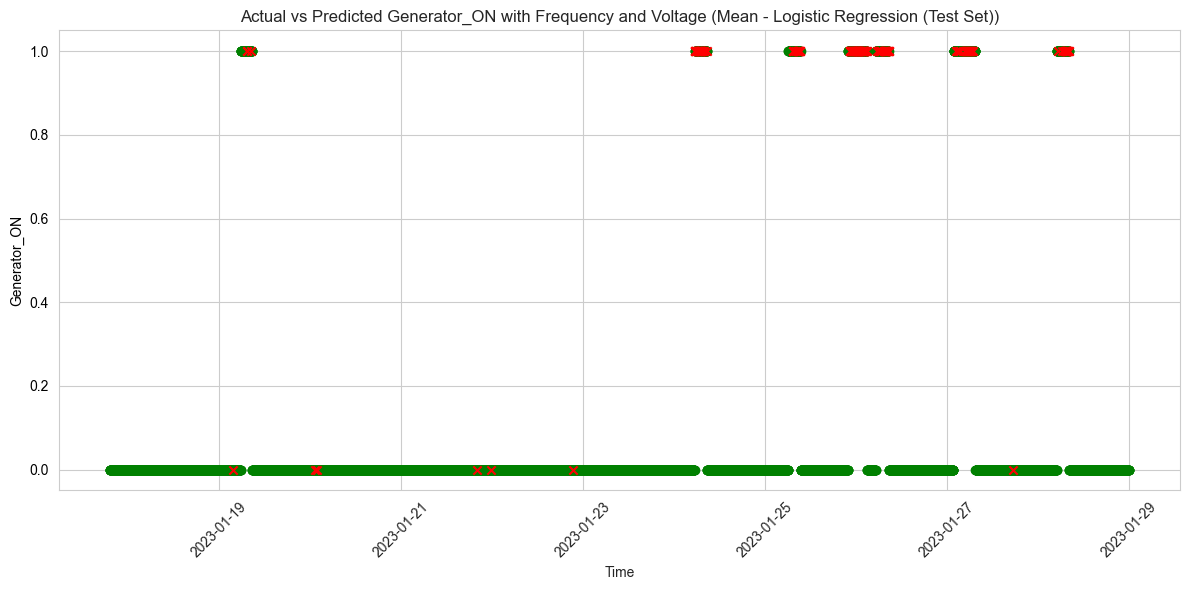

In [55]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

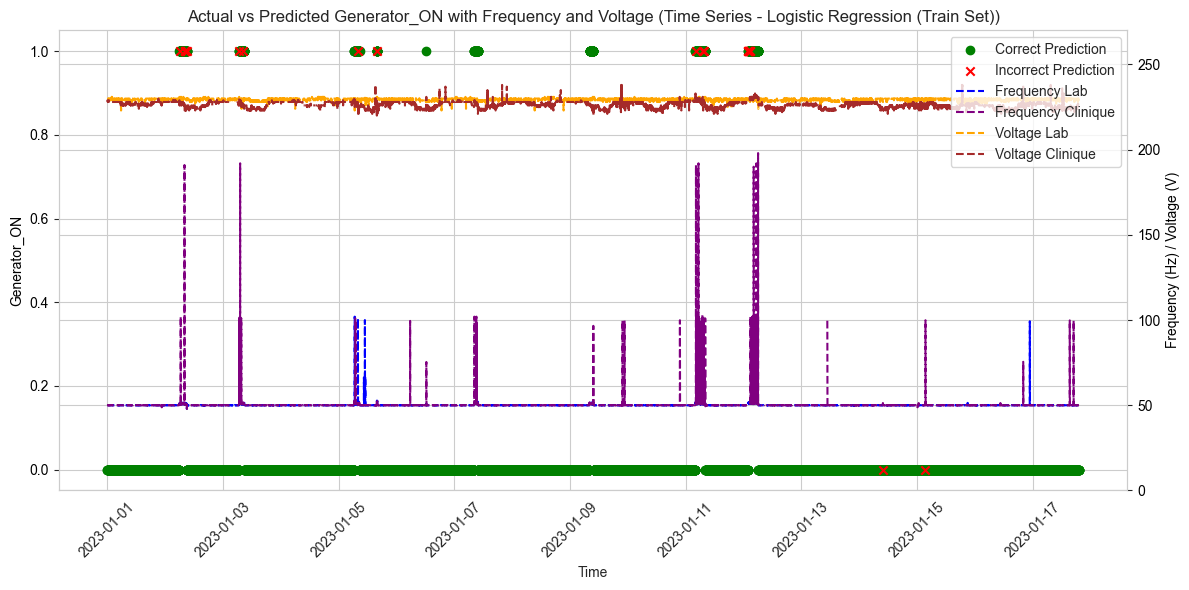

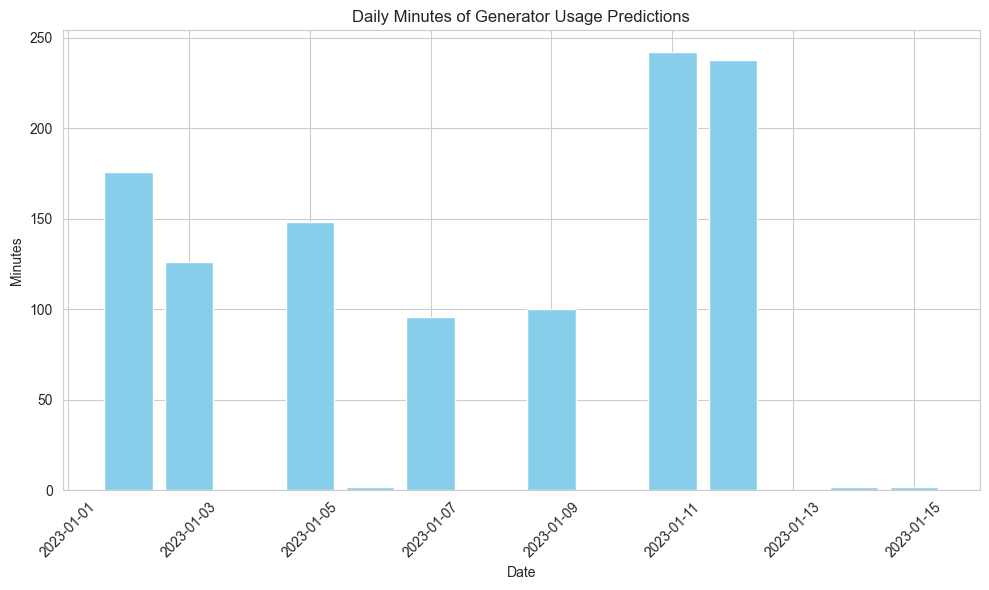

,Date,Count,Minutes,Hours
0,2023-01-02,88,176,2.933333
1,2023-01-03,63,126,2.100000
2,2023-01-05,74,148,2.466667
3,2023-01-06,1,2,0.033333
4,2023-01-07,48,96,1.600000
5,2023-01-09,50,100,1.666667
6,2023-01-11,121,242,4.033333
7,2023-01-12,119,238,3.966667
8,2023-01-14,1,2,0.033333
9,2023-01-15,1,2,0.033333


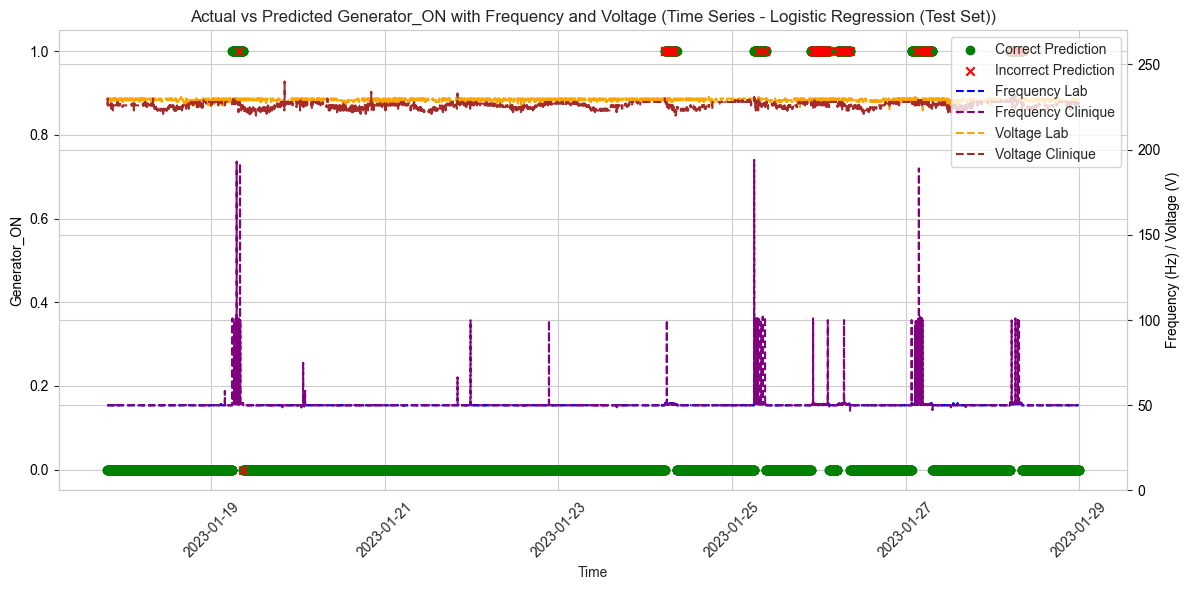

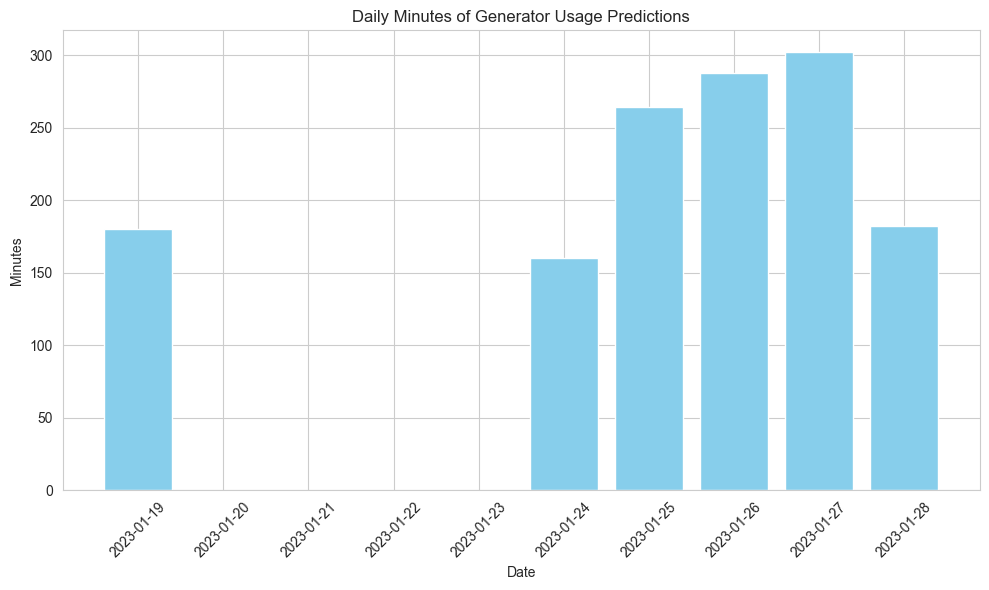

,Date,Count,Minutes,Hours
0,2023-01-19,90,180,3.000000
1,2023-01-24,80,160,2.666667
2,2023-01-25,132,264,4.400000
3,2023-01-26,144,288,4.800000
4,2023-01-27,151,302,5.033333
5,2023-01-28,91,182,3.033333


In [56]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="Time Series - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="Time Series - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)

#### 4.2.2. Using Mean of Voltage and Frequency as a Threshold and Time Series - Random Forrest

Top 15 features sorted by importance:


,Feature,Importance
0,Frequency 09B35150 (Hgr Walikale - Lab),3.122081e-01
1,Frequency 64B734C2 (Hgr Walikale - Cabane),2.476169e-01
5,higher_freq_clinique,1.997581e-01
4,higher_freq_lab,7.083140e-02
8,Freq_delta_lab,4.384928e-02
9,Freq_delta_clinique,4.166051e-02
3,Voltage 64B734C2 (Hgr Walikale - Cabane),1.611141e-02
45,High_delta_freq_clinique,1.517982e-02
12,freq_delta_negative_lab,1.109924e-02
13,freq_delta_negative_clinique,8.674138e-03


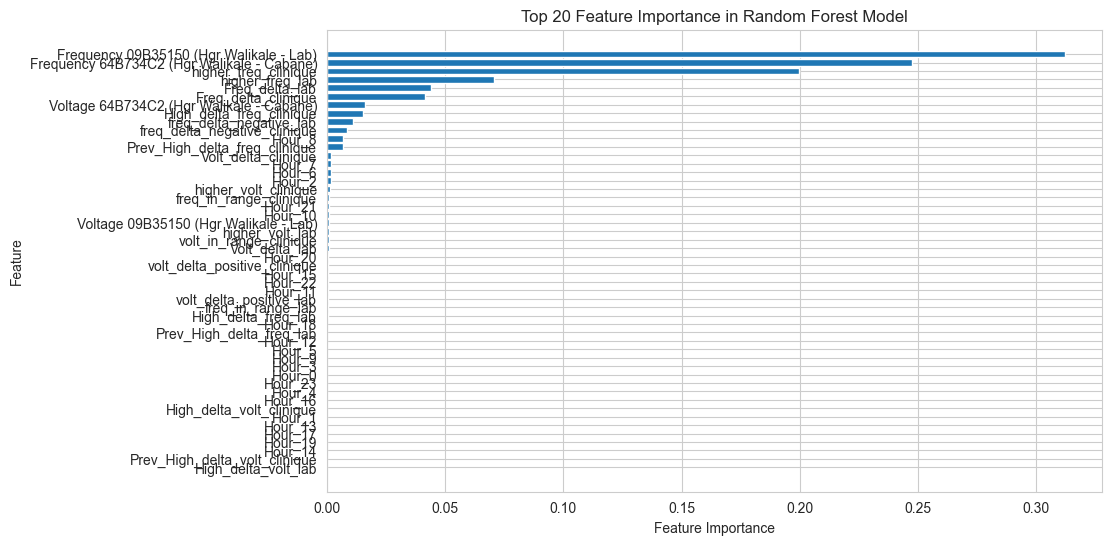

In [57]:
# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

In [58]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.999917328042328
Confusion Matrix:
[[11509     0]
 [    1   586]]
Precision: 1.0
Recall: 0.9982964224872232
Train data prediction distribution:
prediction
False    11510
True       586
Name: count, dtype: int64


In [59]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9986359126984127
Confusion Matrix:
[[7250    0]
 [  11  803]]
Precision: 1.0
Recall: 0.9864864864864865
Test data prediction distribution:
prediction
False    7261
True      803
Name: count, dtype: int64


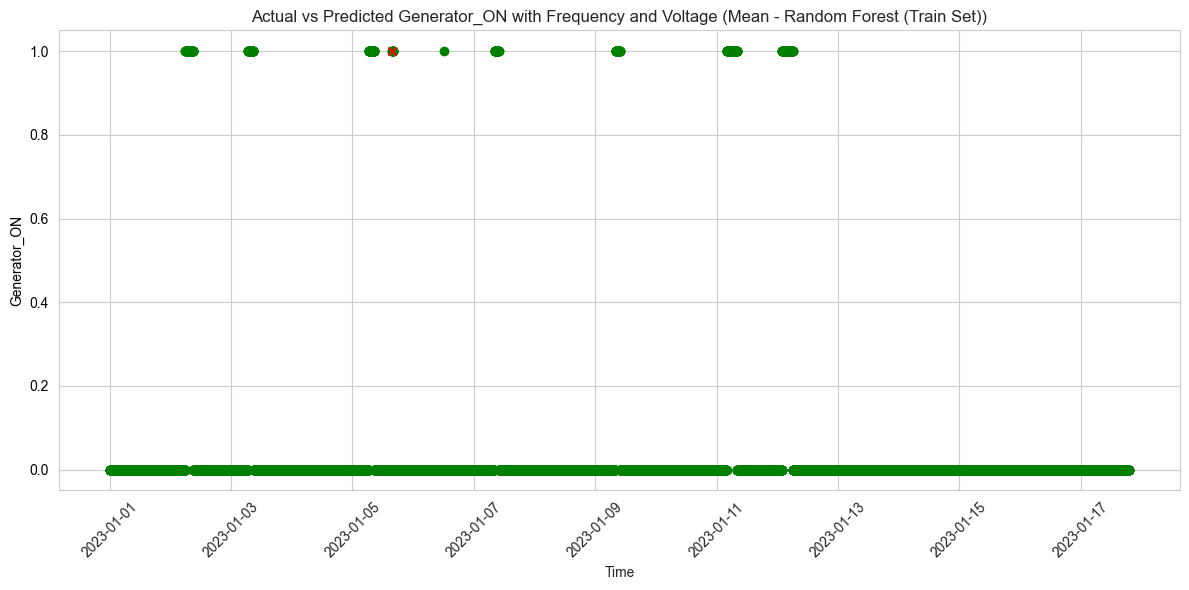

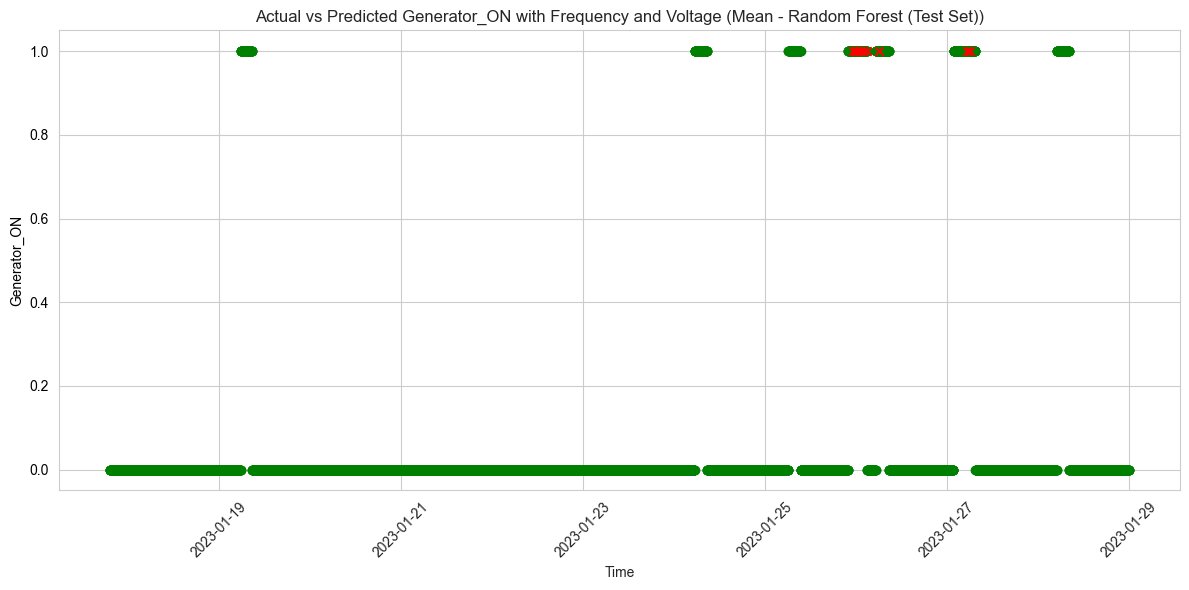

In [60]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

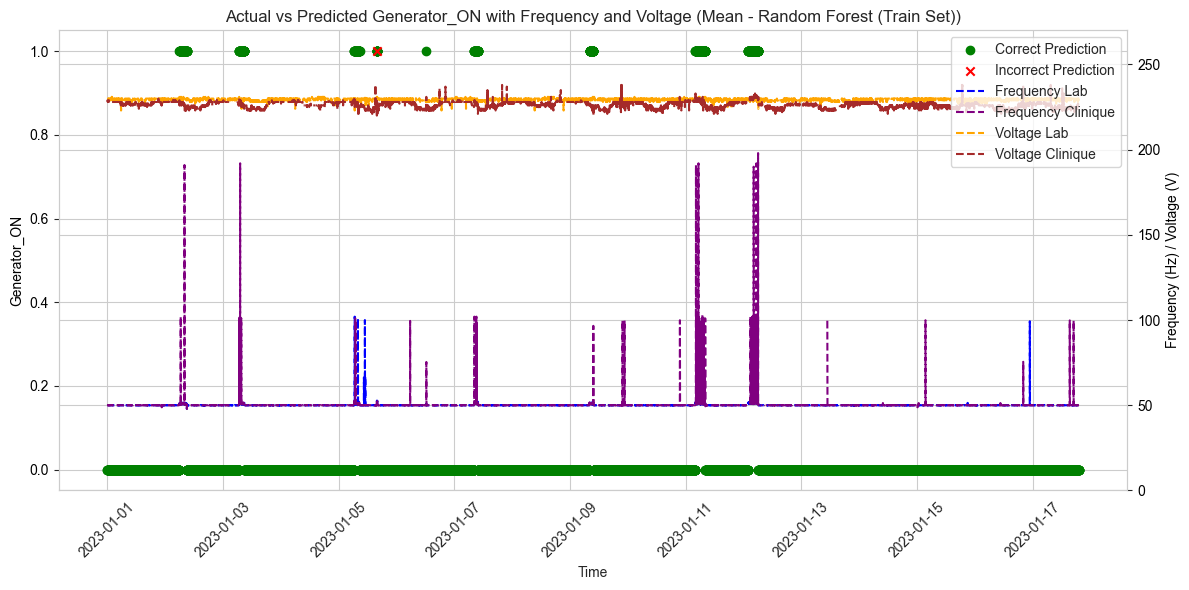

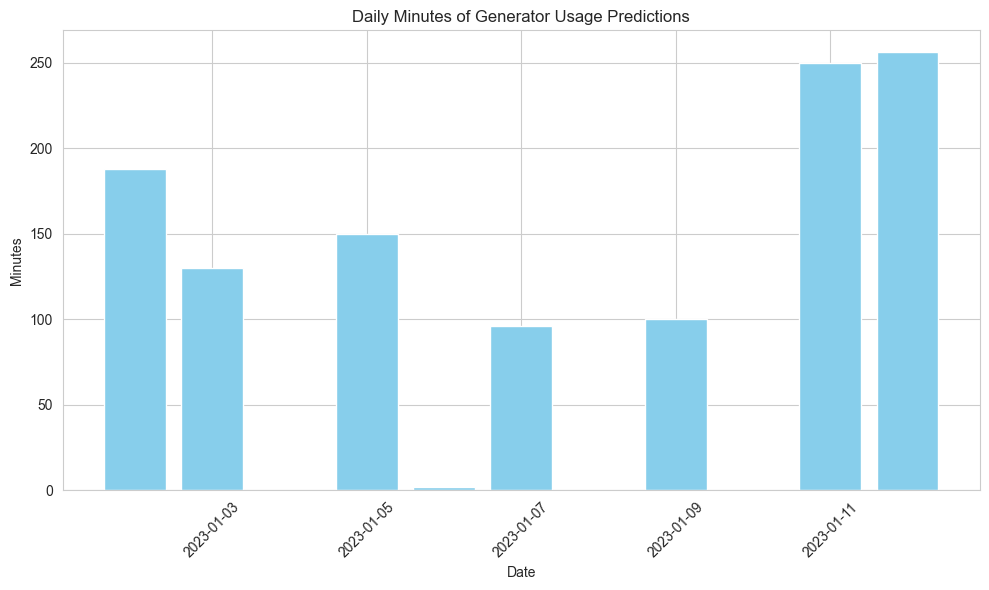

,Date,Count,Minutes,Hours
0,2023-01-02,94,188,3.133333
1,2023-01-03,65,130,2.166667
2,2023-01-05,75,150,2.500000
3,2023-01-06,1,2,0.033333
4,2023-01-07,48,96,1.600000
5,2023-01-09,50,100,1.666667
6,2023-01-11,125,250,4.166667
7,2023-01-12,128,256,4.266667


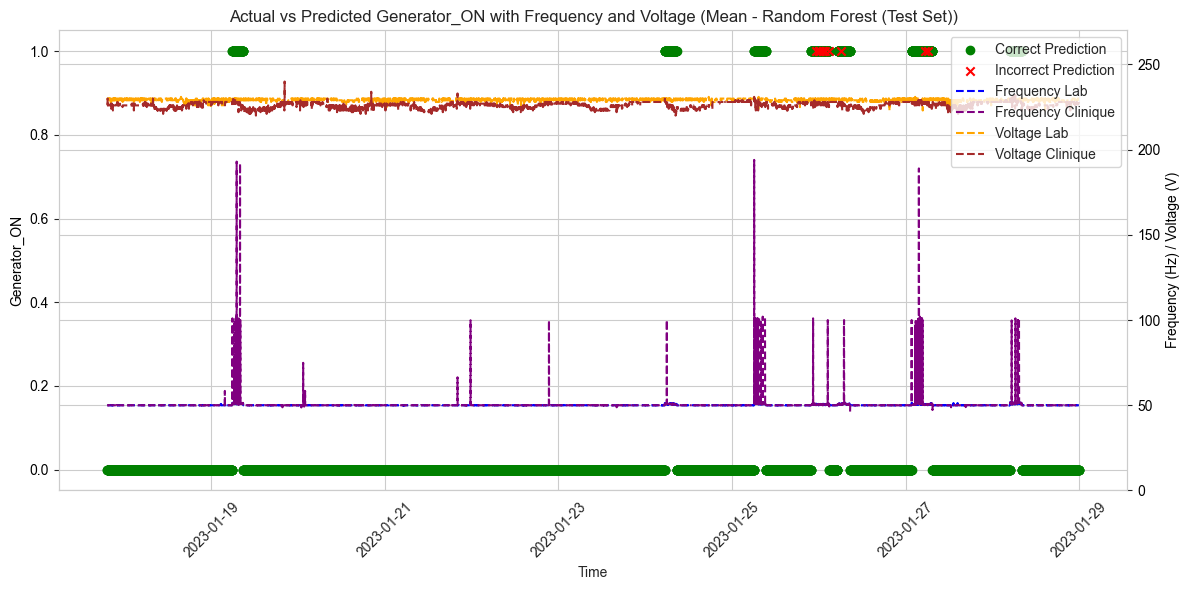

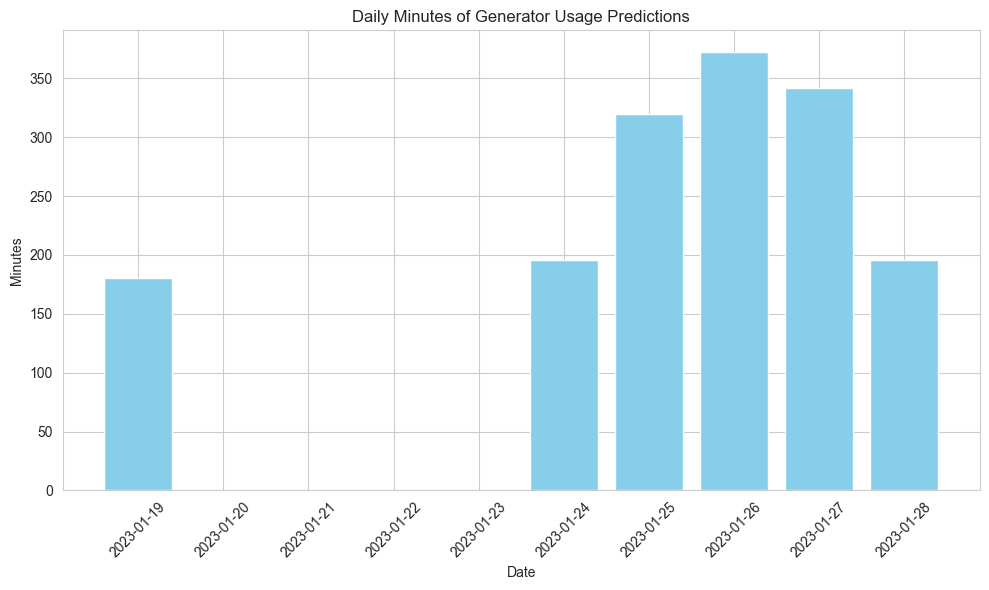

,Date,Count,Minutes,Hours
0,2023-01-19,90,180,3.000000
1,2023-01-24,98,196,3.266667
2,2023-01-25,160,320,5.333333
3,2023-01-26,186,372,6.200000
4,2023-01-27,171,342,5.700000
5,2023-01-28,98,196,3.266667


In [61]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_rf_daily_count = plot_true_predictions_histogram(train_data_ts_rf)
display(train_data_ts_rf_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_rf_daily_count = plot_true_predictions_histogram(test_data_ts_rf)
display(test_data_ts_rf_daily_count)

In [62]:
train_data_ts_rf['Generator_ON'].dtype

dtype('bool')

In [63]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_rf)
display_generator_statistics(test_data_ts_rf)

##### PREDICTION RESULT #####
Actual Minutes: 587 minutes, or 9.78 hours within 201.60 hours
Predicted Minutes: 586 minutes, or 9.77 hours within 201.60 hours
Actual Minutes: 814 minutes, or 13.57 hours within 134.40 hours
Predicted Minutes: 803 minutes, or 13.38 hours within 134.40 hours


#### 4.2.3. Using Mean of Voltage and Frequency as a Threshold and Time Series - XGBoost

In [64]:

# Step 0: Copy rf data
train_data_ts_boost = train_data_ts.copy()
test_data_ts_boost = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_boost, test_data_ts_boost = calculate_mean_flags(train_data_ts_boost, test_data_ts_boost, train_data_base, columns_to_compare)


# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_ts_boost[feature_columns]
y_train = train_data_ts_boost['Generator_ON']

X_test = test_data_ts_boost[feature_columns]
y_test = test_data_ts_boost['Generator_ON']

X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
X_train['Prev_High_delta_volt_lab'] = pd.to_numeric(X_train['Prev_High_delta_volt_lab'], errors='coerce')
X_train['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_train['Prev_High_delta_volt_clinique'], errors='coerce')

X_test['Prev_High_delta_freq_lab'] = pd.to_numeric(X_test['Prev_High_delta_freq_lab'], errors='coerce')
X_test['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_test['Prev_High_delta_freq_clinique'], errors='coerce')
X_test['Prev_High_delta_volt_lab'] = pd.to_numeric(X_test['Prev_High_delta_volt_lab'], errors='coerce')
X_test['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_test['Prev_High_delta_volt_clinique'], errors='coerce')


/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_57091/3060535340.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_57091/3060535340.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
/var/folders/fz/752v568s4vs79b77

#### This section is for XGBoost parameter search using cross validation

In [65]:

'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nfeature

In [66]:
# Use the best parameters from GridSearchCV
best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}

# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_boost['prediction'] = final_model.predict(X_train)
test_data_ts_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_boost['prediction']))

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      7250
        True       1.00      0.99      0.99       814

    accuracy                           1.00      8064
   macro avg       1.00      0.99      1.00      8064
weighted avg       1.00      1.00      1.00      8064

AUC-ROC Score:
0.9999981360671015
Confusion Matrix:
[[7250    0]
 [   9  805]]


In [67]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.999917328042328
Confusion Matrix:
[[11509     0]
 [    1   586]]
Precision: 1.0
Recall: 0.9982964224872232
Train data prediction distribution (XGBoost):
prediction
0    11510
1      586
Name: count, dtype: int64


In [68]:
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_boost['prediction'].value_counts())


Test Set Evaluation (XGBoost):
Accuracy: 0.9988839285714286
Confusion Matrix:
[[7250    0]
 [   9  805]]
Precision: 1.0
Recall: 0.9889434889434889
Test data prediction distribution (XGBoost):
prediction
0    7259
1     805
Name: count, dtype: int64


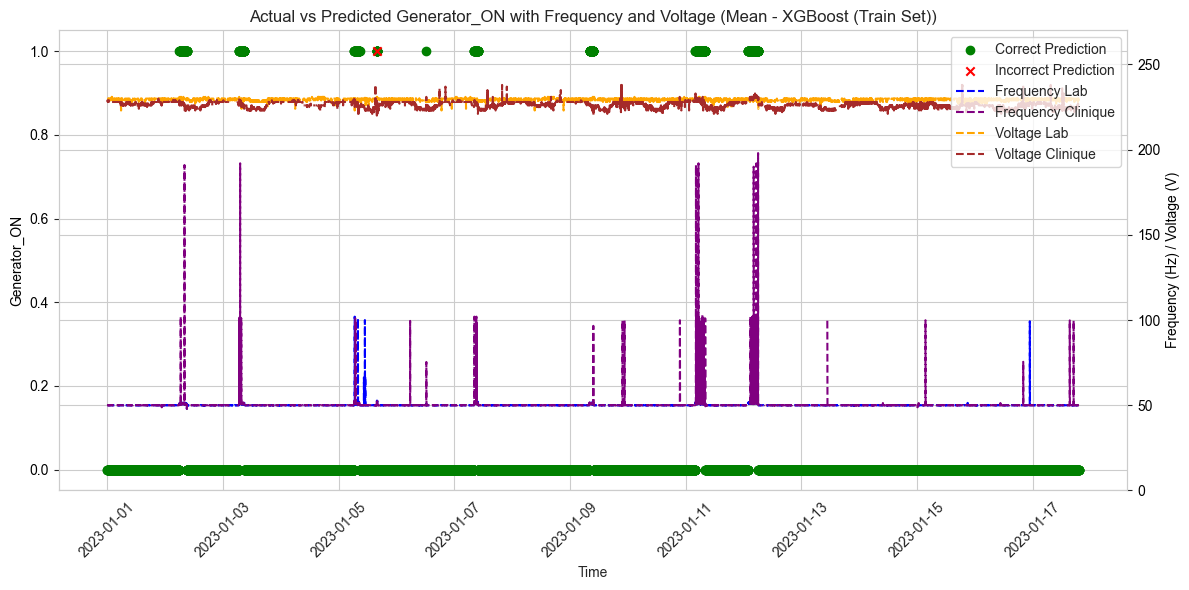

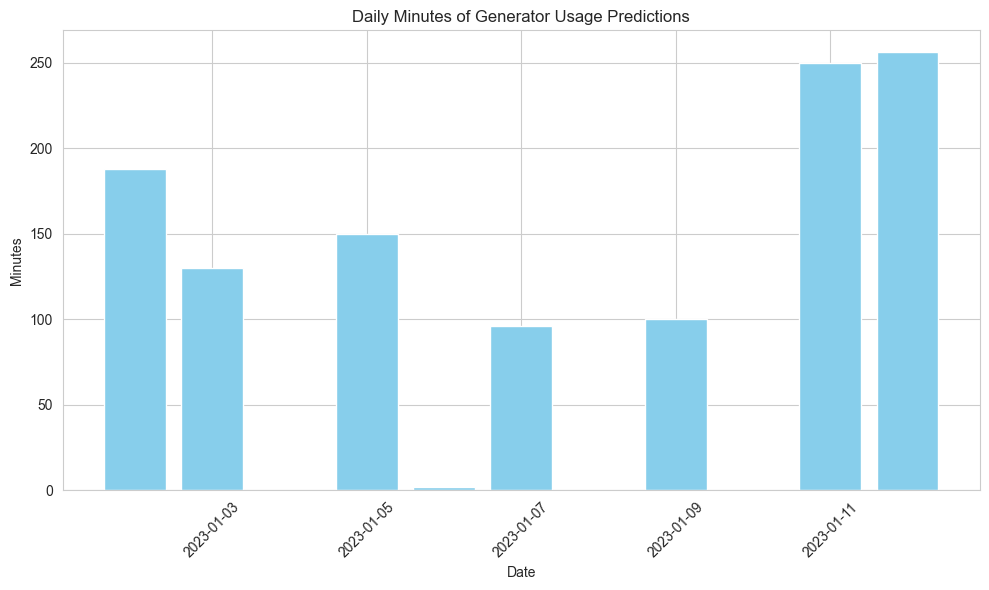

,Date,Count,Minutes,Hours
0,2023-01-02,94,188,3.133333
1,2023-01-03,65,130,2.166667
2,2023-01-05,75,150,2.500000
3,2023-01-06,1,2,0.033333
4,2023-01-07,48,96,1.600000
5,2023-01-09,50,100,1.666667
6,2023-01-11,125,250,4.166667
7,2023-01-12,128,256,4.266667


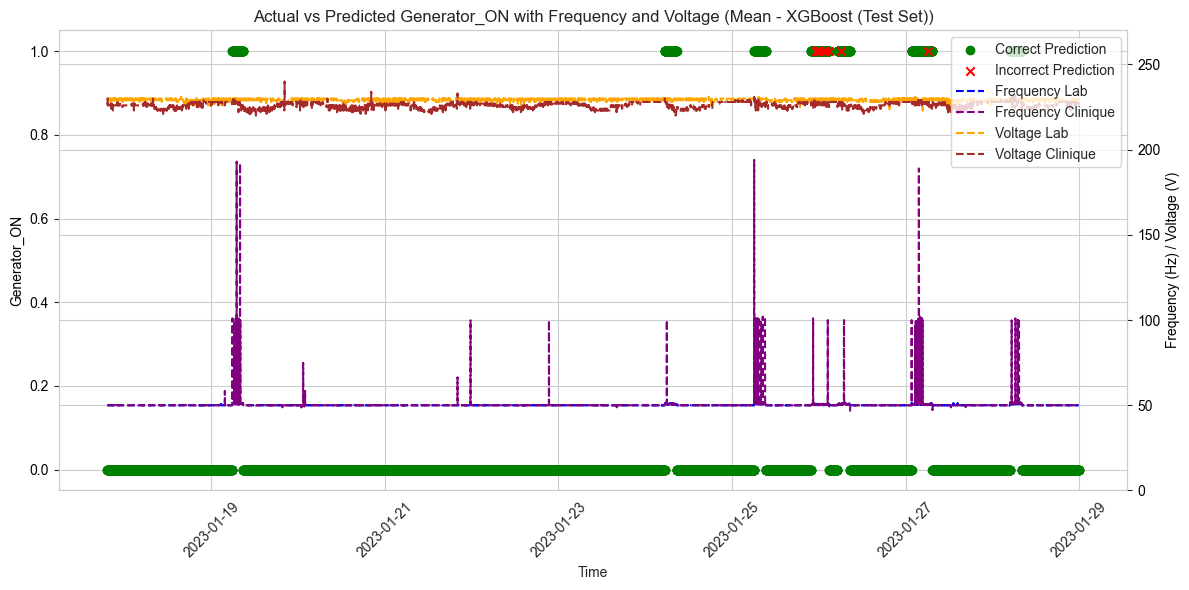

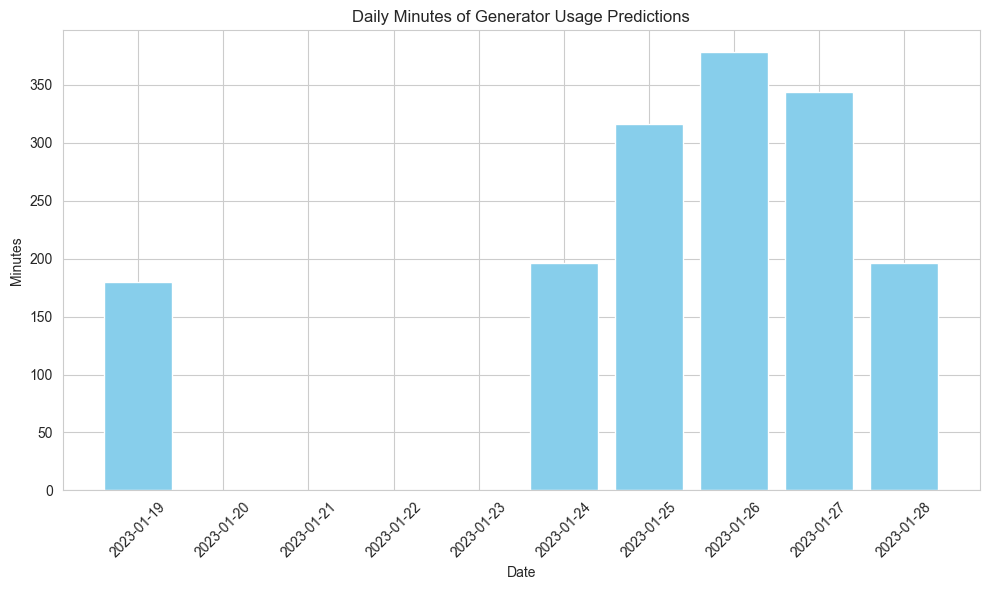

,Date,Count,Minutes,Hours
0,2023-01-19,90,180,3.000000
1,2023-01-24,98,196,3.266667
2,2023-01-25,158,316,5.266667
3,2023-01-26,189,378,6.300000
4,2023-01-27,172,344,5.733333
5,2023-01-28,98,196,3.266667


In [69]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_boost, model_name="Mean - XGBoost (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_boost_daily_count = plot_true_predictions_histogram(train_data_ts_boost)
display(train_data_ts_boost_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_boost, model_name="Mean - XGBoost (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_boost_daily_count = plot_true_predictions_histogram(test_data_ts_boost)
display(test_data_ts_boost_daily_count)

In [70]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_boost)
display_generator_statistics(test_data_ts_boost)

##### PREDICTION RESULT #####
Actual Minutes: 587 minutes, or 9.78 hours within 201.60 hours
Predicted Minutes: 586 minutes, or 9.77 hours within 201.60 hours
Actual Minutes: 814 minutes, or 13.57 hours within 134.40 hours
Predicted Minutes: 805 minutes, or 13.42 hours within 134.40 hours


### 4.3. Correlation Feature

In this section we're applying additional feature using the : 
- Hidden Markov Model : Detecting states

In [71]:
### Applying Hidden Markov Model

# Insert variables
n_states = 5
hmm_columns = [freq_a, freq_b, volt_a, volt_b]

# Make copies of original train and test sets
train_data_ts_co = train_data_ts.copy()
test_data_ts_co = test_data_ts.copy()

# Sort by Time
train_data_ts_co.sort_values('Time', ascending=True, inplace=True)
test_data_ts_co.sort_values('Time', ascending=True, inplace=True)

# Clean NaNs, infs, and low-variance columns
valid_hmm_columns = []

for col in hmm_columns:
    if col in train_data_ts_co.columns and col in test_data_ts_co.columns:
        values_train = train_data_ts_co[col].replace([np.inf, -np.inf], 0).fillna(0)
        values_test = test_data_ts_co[col].replace([np.inf, -np.inf], 0).fillna(0)

        if values_train.std() < 1e-3:
            print(f"⚠️ Column {col} has too low variance (std={values_train.std():.5f}), skipping HMM fitting.")
        else:
            train_data_ts_co[col] = values_train
            test_data_ts_co[col] = values_test
            valid_hmm_columns.append(col)

hmm_columns = valid_hmm_columns  # update hmm_columns

# Train HMMs on train set
train_data_ts_co, hmm_models, hmm_features = generate_hmm(
    train_data_ts_co,
    hmm_columns,
    n_states=n_states
)

# Apply HMMs to test set
def apply_hmm(df, columns, hmm_models):
    """
    Apply trained HMM models to a new dataset and generate one-hot encoded HMM states.

    Parameters:
    - df (DataFrame): The DataFrame to apply HMMs to.
    - columns (list): List of feature columns to apply HMMs.
    - hmm_models (dict): Trained HMM models from the training set.

    Returns:
    - df_result (DataFrame): DataFrame with added HMM states and one-hot encoded features.
    """
    df_result = df.copy()
    hmm_feature_cols = []

    for col in columns:
        if col not in df_result.columns:
            print(f"⚠️ Column {col} missing in DataFrame. Skipping...")
            continue

        X = df_result[col].replace([np.inf, -np.inf], 0).fillna(0).to_numpy().reshape(-1, 1)
        state_col = f'HMM_State_{col}'
        model = hmm_models.get(col)

        if model is not None:
            df_result[state_col] = model.predict(X)

            # One-hot encode HMM state
            dummies = pd.get_dummies(df_result[state_col], prefix=state_col)
            df_result = pd.concat([df_result, dummies], axis=1)
            hmm_feature_cols.extend(dummies.columns.tolist())
        else:
            print(f"⚠️ No trained HMM model found for {col}. Skipping...")

    return df_result

# Now apply
test_data_ts_co = apply_hmm(test_data_ts_co, hmm_columns, hmm_models)

# Display result
display(train_data_ts_co)
display(test_data_ts_co)


Model is not converging.  Current: 56132.37514738831 is not greater than 56135.44389902468. Delta is -3.068751636368688
Model is not converging.  Current: 51245.152299451336 is not greater than 51248.1100247446. Delta is -2.957725293264957
Model is not converging.  Current: 57175.34364048497 is not greater than 57177.44023251558. Delta is -2.096592030611646
Model is not converging.  Current: 8846.237900613154 is not greater than 8848.58835068672. Delta is -2.3504500735652982


,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_1,HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_2,HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_3,HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_4,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane),HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_0,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_1,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_2,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_3,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_4
0,2023-01-01 00:00:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,True,False,False,3,False,False,False,True,False
1,2023-01-01 00:02:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,True,False,False,3,False,False,False,True,False
2,2023-01-01 00:04:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,True,False,False,3,False,False,False,True,False
3,2023-01-01 00:06:00,50.0,50.0,230.0,229.0,False,False,False,True,True,...,False,True,False,False,0,True,False,False,False,False
4,2023-01-01 00:08:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,True,False,False,3,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6061,2023-01-17 19:02:00,50.0,50.0,229.0,226.0,False,False,False,False,False,...,False,False,True,False,4,False,False,False,False,True
6062,2023-01-17 19:04:00,50.0,50.0,229.0,226.0,False,False,False,False,False,...,False,False,True,False,4,False,False,False,False,True
6063,2023-01-17 19:06:00,50.0,50.0,230.0,226.0,False,False,False,True,False,...,False,True,False,False,4,False,False,False,False,True
6064,2023-01-17 19:08:00,50.0,50.0,230.0,226.0,False,False,False,True,False,...,False,True,False,False,4,False,False,False,False,True


,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_1,HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_2,HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_3,HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_4,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane),HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_0,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_1,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_2,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_3,HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_4
6066,2023-01-17 19:12:00,50.0,50.0,229.0,226.0,False,False,False,False,False,...,False,False,False,True,0,True,False,False,False,False
6067,2023-01-17 19:14:00,50.0,50.0,229.0,226.0,False,False,False,False,False,...,False,False,True,False,0,True,False,False,False,False
6068,2023-01-17 19:16:00,50.0,50.0,230.0,230.0,False,False,False,True,True,...,False,True,False,False,0,True,False,False,False,False
6069,2023-01-17 19:18:00,50.0,50.1,230.0,228.0,False,False,False,True,True,...,False,True,False,False,3,False,False,False,True,False
6070,2023-01-17 19:20:00,50.0,50.0,230.0,226.0,False,False,False,True,False,...,False,True,False,False,4,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14875,2023-01-28 23:50:00,50.0,0.0,230.0,0.0,False,False,False,True,False,...,False,True,False,False,1,False,True,False,False,False
14876,2023-01-28 23:52:00,50.0,50.0,230.0,227.0,False,False,False,True,True,...,False,True,False,False,4,False,False,False,False,True
14877,2023-01-28 23:54:00,50.0,0.0,230.0,0.0,False,False,False,True,False,...,False,True,False,False,1,False,True,False,False,False
14878,2023-01-28 23:56:00,50.0,50.0,230.0,228.0,False,False,False,True,True,...,False,True,False,False,3,False,False,False,True,False



Mean values per HMM state for Frequency 09B35150 (Hgr Walikale - Lab):
HMM_State_Frequency 09B35150 (Hgr Walikale - Lab)
1      0.000000
0     50.000000
3     50.395539
4     66.550000
2    100.575000
Name: Frequency 09B35150 (Hgr Walikale - Lab), dtype: float64


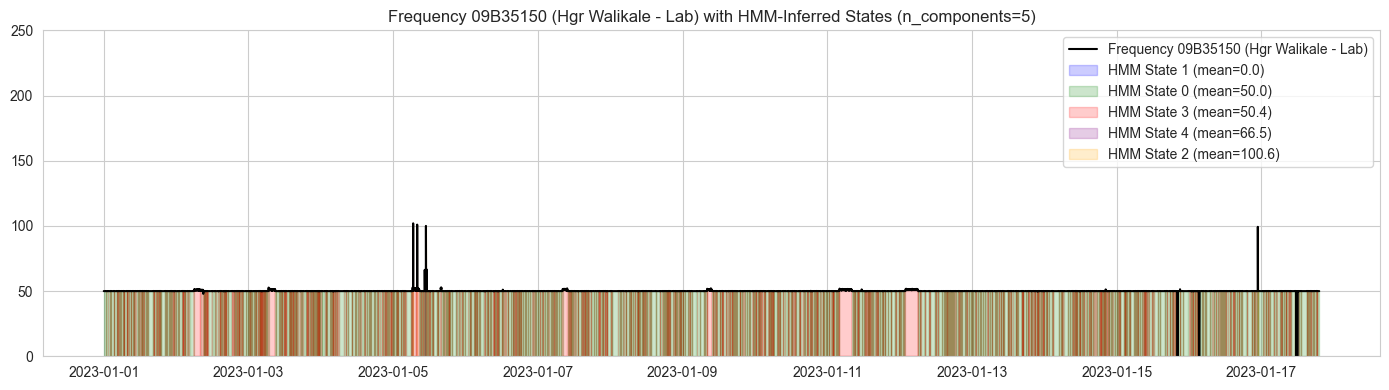


Mean values per HMM state for Frequency 64B734C2 (Hgr Walikale - Cabane):
HMM_State_Frequency 64B734C2 (Hgr Walikale - Cabane)
1     24.837253
4     50.000000
0     50.052244
2    100.761017
3    192.000000
Name: Frequency 64B734C2 (Hgr Walikale - Cabane), dtype: float64


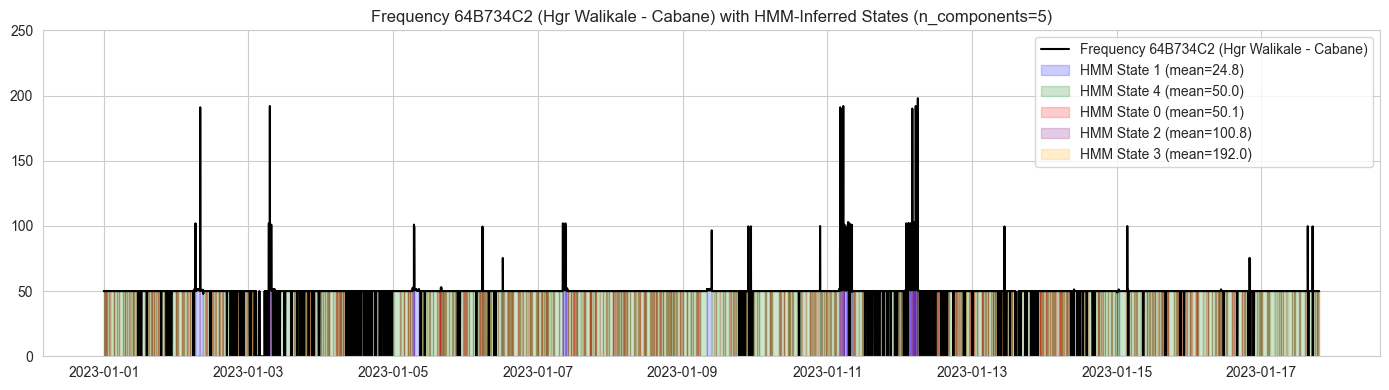


Mean values per HMM state for Voltage 09B35150 (Hgr Walikale - Lab):
HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)
1      0.000000
0    228.000000
4    228.216814
3    229.000000
2    230.000000
Name: Voltage 09B35150 (Hgr Walikale - Lab), dtype: float64


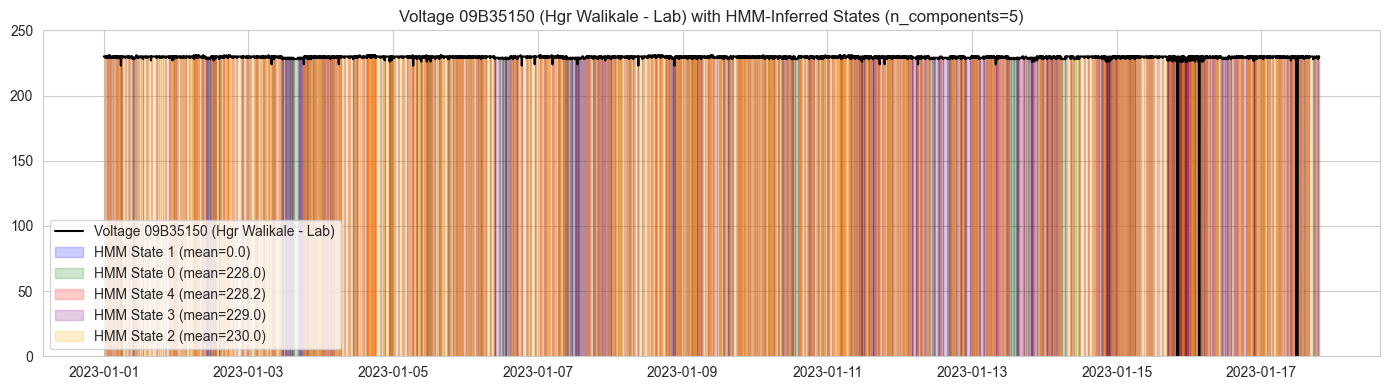


Mean values per HMM state for Voltage 64B734C2 (Hgr Walikale - Cabane):
HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)
1      0.000000
2    224.123964
4    226.336415
3    228.000000
0    228.697674
Name: Voltage 64B734C2 (Hgr Walikale - Cabane), dtype: float64


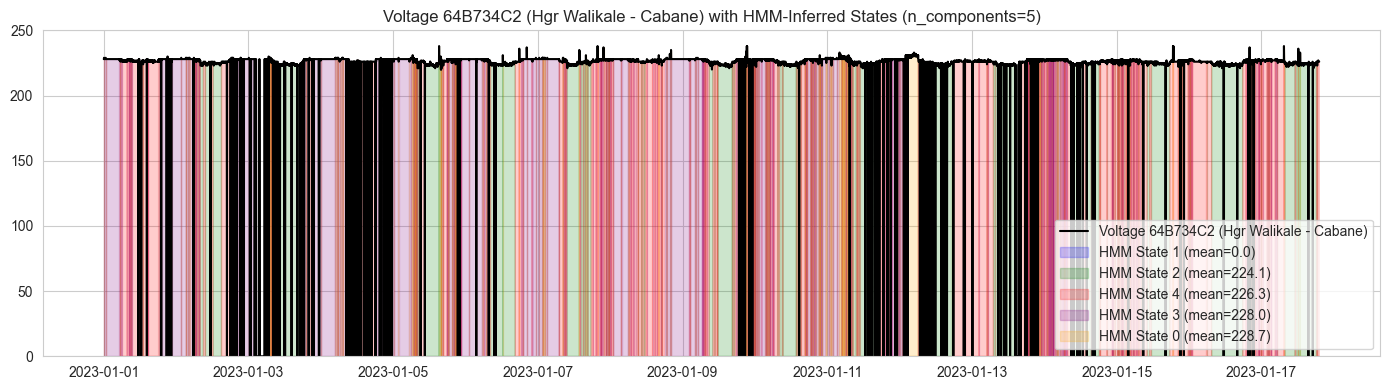

In [72]:
#### SHOWING THE RESULT OF HMM SIGNAL
    
# Create the signal
start_date = '2023-01-01 00:00:00'
finished_date = '2023-01-28 23:59:59'
filtered_data = train_data_ts_co[(train_data_ts_co['Time'] >= start_date) & (train_data_ts_co['Time'] <= finished_date)]
filtered_data.sort_values('Time', ascending=True, inplace=True)

show_hmm_result(filtered_data, hmm_columns, y_max=250)

In [73]:
hmm_features

['HMM_State_Frequency 09B35150 (Hgr Walikale - Lab)_0',
 'HMM_State_Frequency 09B35150 (Hgr Walikale - Lab)_1',
 'HMM_State_Frequency 09B35150 (Hgr Walikale - Lab)_2',
 'HMM_State_Frequency 09B35150 (Hgr Walikale - Lab)_3',
 'HMM_State_Frequency 09B35150 (Hgr Walikale - Lab)_4',
 'HMM_State_Frequency 64B734C2 (Hgr Walikale - Cabane)_0',
 'HMM_State_Frequency 64B734C2 (Hgr Walikale - Cabane)_1',
 'HMM_State_Frequency 64B734C2 (Hgr Walikale - Cabane)_2',
 'HMM_State_Frequency 64B734C2 (Hgr Walikale - Cabane)_3',
 'HMM_State_Frequency 64B734C2 (Hgr Walikale - Cabane)_4',
 'HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_0',
 'HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_1',
 'HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_2',
 'HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_3',
 'HMM_State_Voltage 09B35150 (Hgr Walikale - Lab)_4',
 'HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_0',
 'HMM_State_Voltage 64B734C2 (Hgr Walikale - Cabane)_1',
 'HMM_State_Voltage 64B734C2 (Hgr Walikal

#### 4.3.1. Adding the Correlation functions (HMM and Ruptures)  - Logistic Regression

Train Accuracy: 1.00
Test Accuracy: 0.99
Top 20 features sorted by absolute coefficient value:


,Feature,Coefficient
58,HMM_State_Frequency 64B734C2 (Hgr Walikale - C...,3.292903
5,higher_freq_clinique,2.934348
61,HMM_State_Frequency 64B734C2 (Hgr Walikale - C...,-2.884156
4,higher_freq_lab,2.229989
22,Hour_2,2.009844
12,freq_delta_negative_lab,1.836257
28,Hour_8,1.824081
55,HMM_State_Frequency 09B35150 (Hgr Walikale - L...,1.735669
52,HMM_State_Frequency 09B35150 (Hgr Walikale - L...,-1.551520
27,Hour_7,1.134968


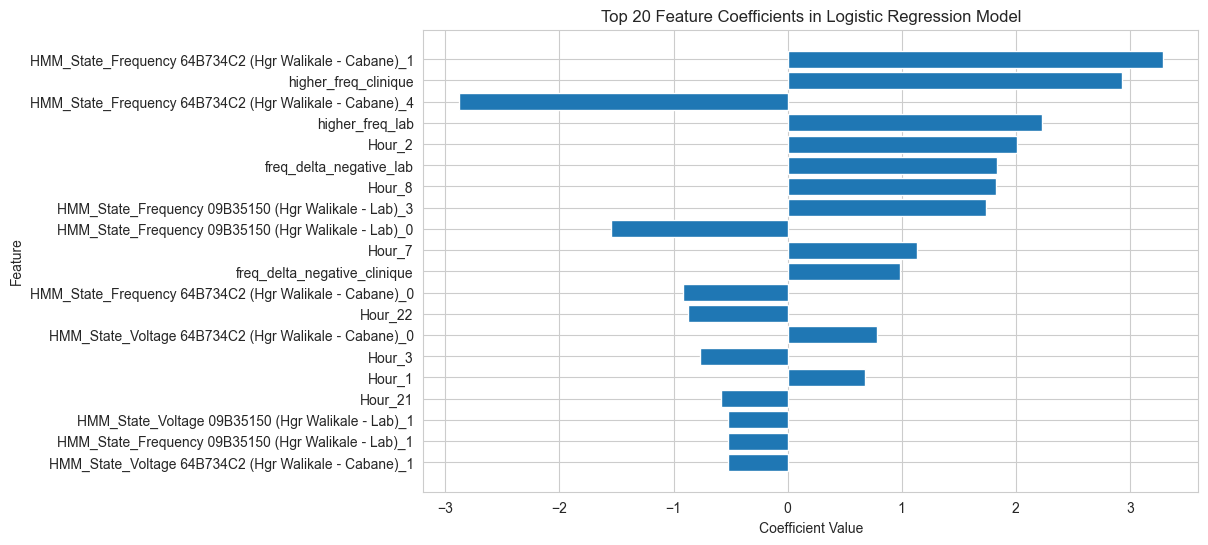

In [74]:
# Step 1: Create copies of the original data
train_data_ts_co_lg = train_data_ts_co.copy()
test_data_ts_co_lg = test_data_ts_co.copy()

# Calculate the mean flags
train_data_ts_co_lg, test_data_ts_co_lg = calculate_mean_flags(
    train_data_ts_co_lg,
    test_data_ts_co_lg,
    train_data_base,
    columns_to_compare
)

# Define your static feature columns
static_feature_columns = [
    freq_a, freq_b, volt_a, volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Combine static features + HMM-generated features
feature_columns = static_feature_columns + hmm_features

# Prepare X and y
X_train = train_data_ts_co_lg[feature_columns]
y_train = train_data_ts_co_lg['Generator_ON']

# Fix X_test: reindex so missing columns (e.g., HMM states) are filled with 0
X_test = test_data_ts_co_lg.reindex(columns=feature_columns, fill_value=0)
y_test = test_data_ts_co_lg['Generator_ON']

# Fill any remaining NaN values (very safe)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_co_lg['prediction'] = clf.predict(X_train)
test_data_ts_co_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_co_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_co_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients
coefficients = clf.coef_[0]

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficient
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Most important on top
plt.show()

In [75]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_co_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_co_lg['prediction'].value_counts())

# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_co_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_co_lg['prediction'].value_counts())

print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_lg)
display_generator_statistics(test_data_ts_co_lg)

Train Set Evaluation:
Accuracy: 0.9990906084656085
Confusion Matrix:
[[11506     3]
 [    8   579]]
Precision: 0.9948453608247423
Recall: 0.9863713798977853
Train data prediction distribution:
prediction
False    11514
True       582
Name: count, dtype: int64
Test Set Evaluation:
Accuracy: 0.9929315476190477
Confusion Matrix:
[[7249    1]
 [  56  758]]
Precision: 0.9986824769433466
Recall: 0.9312039312039312
Test data prediction distribution:
prediction
False    7305
True      759
Name: count, dtype: int64
##### PREDICTION RESULT #####
Actual Minutes: 587 minutes, or 9.78 hours within 201.60 hours
Predicted Minutes: 582 minutes, or 9.70 hours within 201.60 hours
Actual Minutes: 814 minutes, or 13.57 hours within 134.40 hours
Predicted Minutes: 759 minutes, or 12.65 hours within 134.40 hours


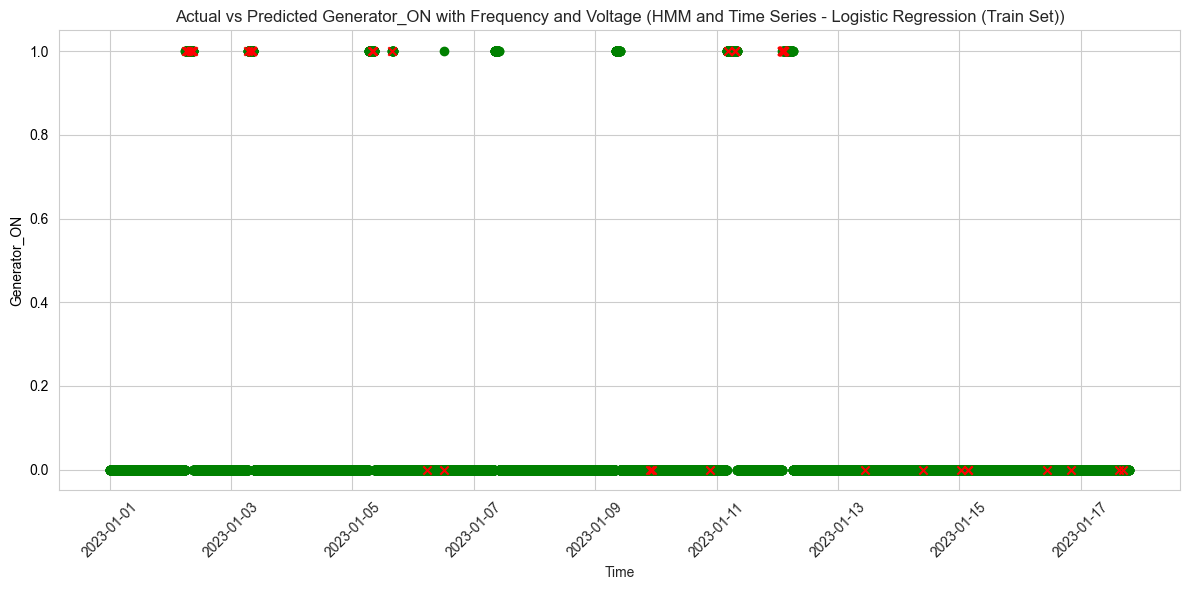

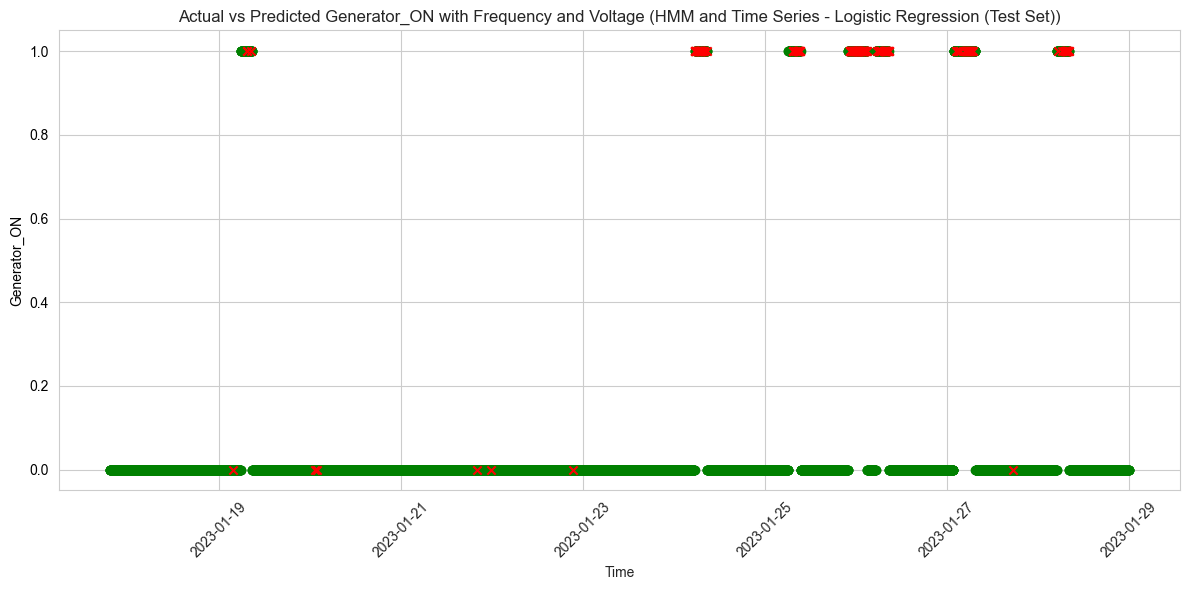

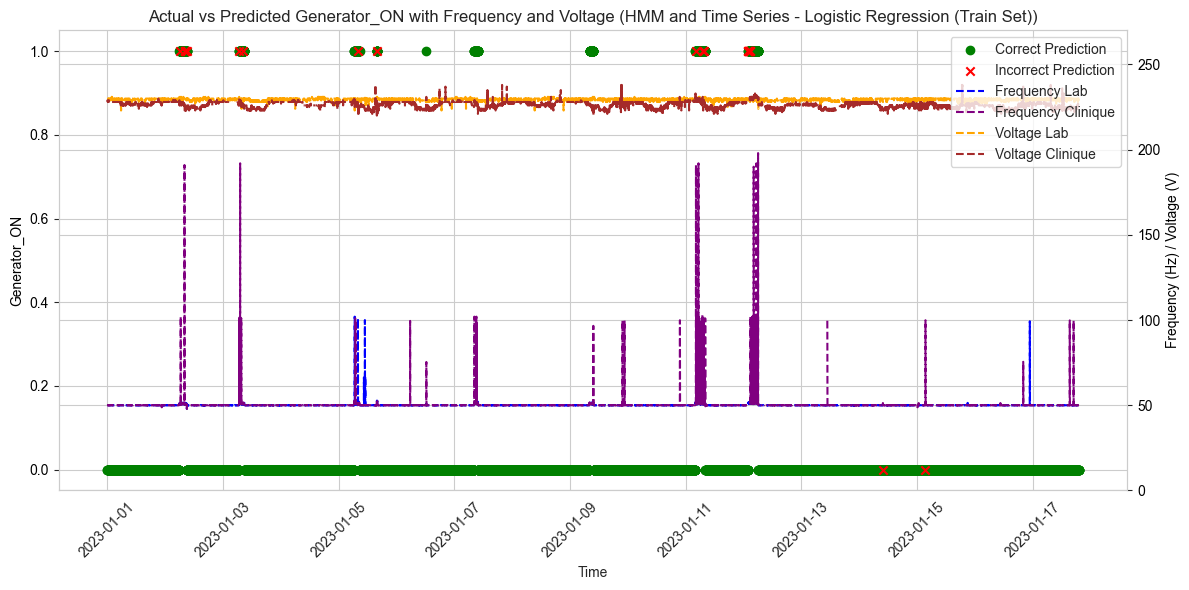

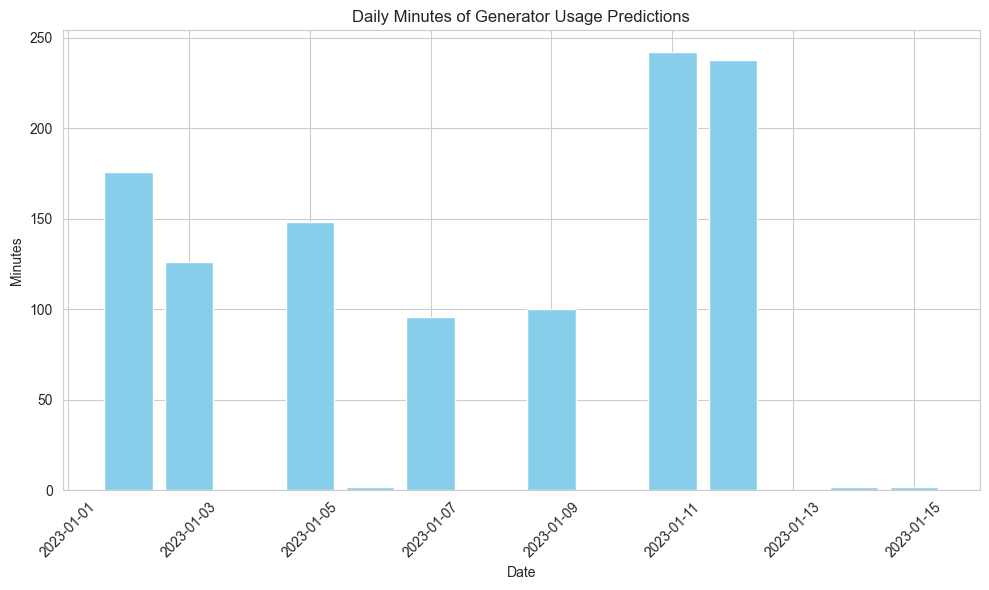

,Date,Count,Minutes,Hours
0,2023-01-02,88,176,2.933333
1,2023-01-03,63,126,2.100000
2,2023-01-05,74,148,2.466667
3,2023-01-06,1,2,0.033333
4,2023-01-07,48,96,1.600000
5,2023-01-09,50,100,1.666667
6,2023-01-11,121,242,4.033333
7,2023-01-12,119,238,3.966667
8,2023-01-14,1,2,0.033333
9,2023-01-15,1,2,0.033333


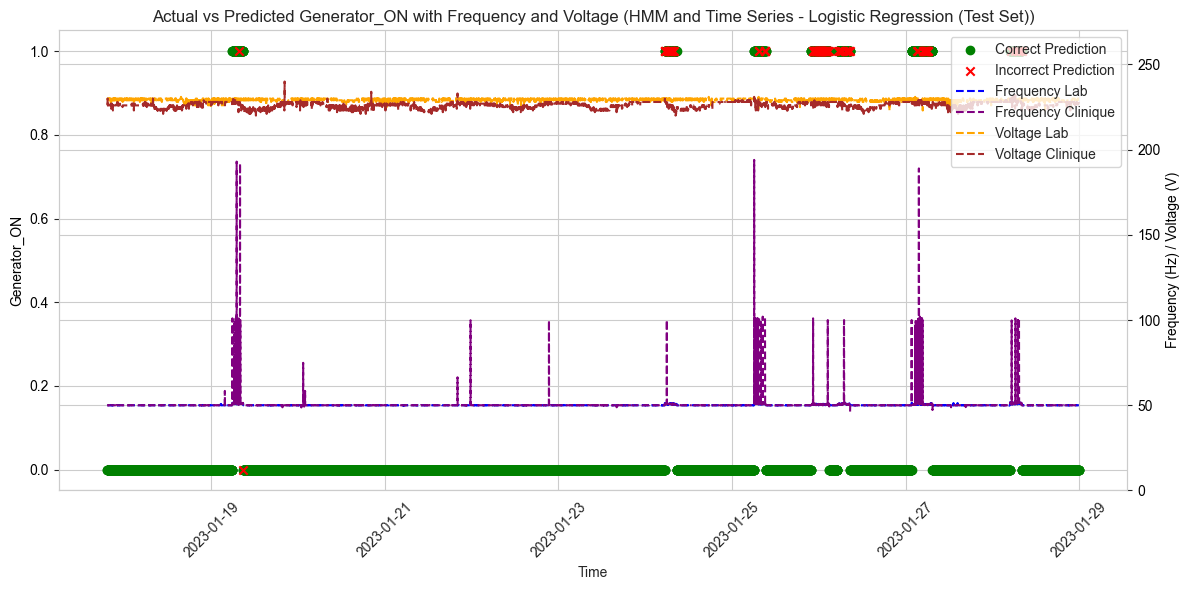

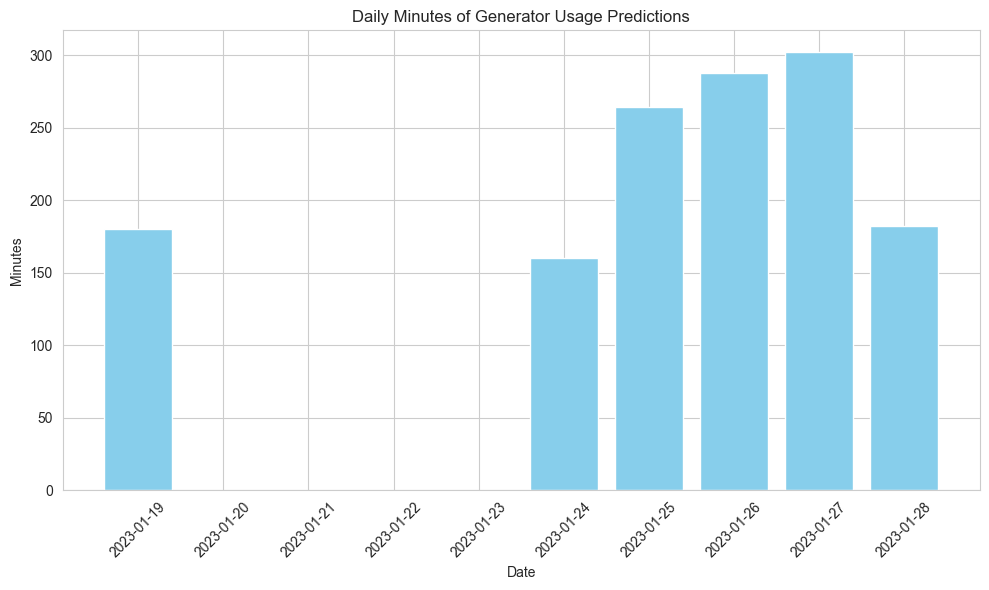

,Date,Count,Minutes,Hours
0,2023-01-19,90,180,3.000000
1,2023-01-24,80,160,2.666667
2,2023-01-25,132,264,4.400000
3,2023-01-26,144,288,4.800000
4,2023-01-27,151,302,5.033333
5,2023-01-28,91,182,3.033333


In [76]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="HMM and Time Series - Logistic Regression (Train Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="HMM and Time Series - Logistic Regression (Test Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="HMM and Time Series - Logistic Regression (Train Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="HMM and Time Series - Logistic Regression (Test Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)


#### 4.3.2. Adding the Correlation functions (HMM)  - Random Forrest

Top 20 features sorted by importance:


,Feature,Importance
1,Frequency 64B734C2 (Hgr Walikale - Cabane),0.240618
0,Frequency 09B35150 (Hgr Walikale - Lab),0.235318
5,higher_freq_clinique,0.108455
58,HMM_State_Frequency 64B734C2 (Hgr Walikale - C...,0.085262
8,Freq_delta_lab,0.049196
55,HMM_State_Frequency 09B35150 (Hgr Walikale - L...,0.039405
61,HMM_State_Frequency 64B734C2 (Hgr Walikale - C...,0.039386
4,higher_freq_lab,0.036285
52,HMM_State_Frequency 09B35150 (Hgr Walikale - L...,0.031696
9,Freq_delta_clinique,0.028083


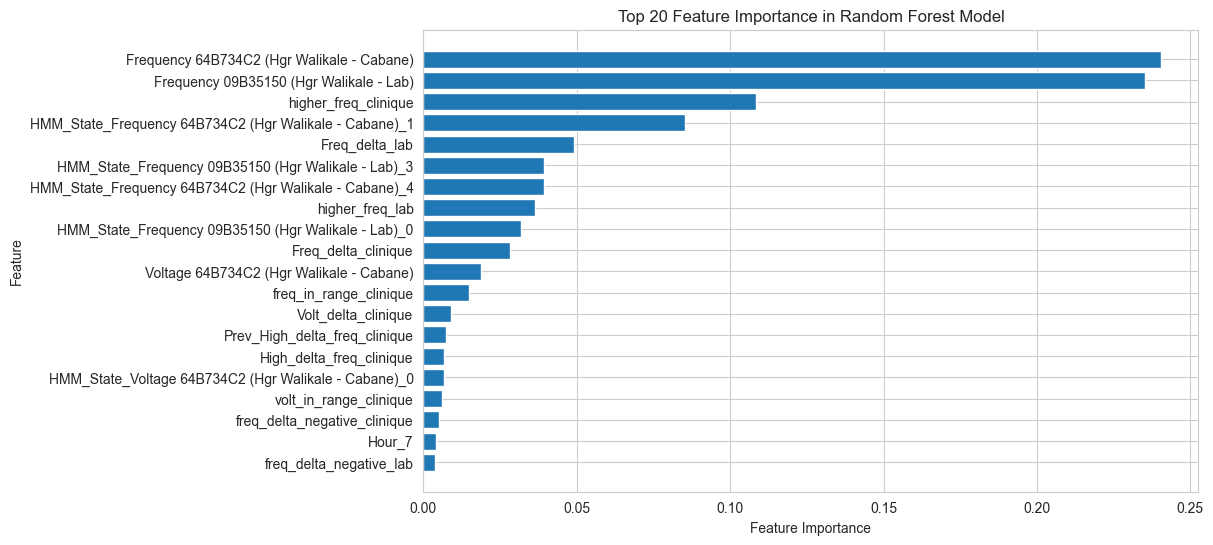

In [77]:
# Step 1: Create copies of the original data
train_data_ts_co_rf = train_data_ts_co.copy()
test_data_ts_co_rf = test_data_ts_co.copy()


# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_co_rf[feature_columns]
y_train = train_data_ts_co_rf['Generator_ON']

X_test = test_data_ts_co_rf.reindex(columns=feature_columns, fill_value=0)
y_test = test_data_ts_co_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_co_rf['prediction'] = clf.predict(X_train)
test_data_ts_co_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 15 most important features
print("Top 20 features sorted by importance:")
display(top_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

Train Set Evaluation:
Accuracy: 0.999917328042328
Confusion Matrix:
[[11509     0]
 [    1   586]]
Precision: 1.0
Recall: 0.9982964224872232
Train data prediction distribution:
prediction
False    11510
True       586
Name: count, dtype: int64
Test Set Evaluation:
Accuracy: 0.9990079365079365
Confusion Matrix:
[[7250    0]
 [   8  806]]
Precision: 1.0
Recall: 0.9901719901719902
Test data prediction distribution:
prediction
False    7258
True      806
Name: count, dtype: int64


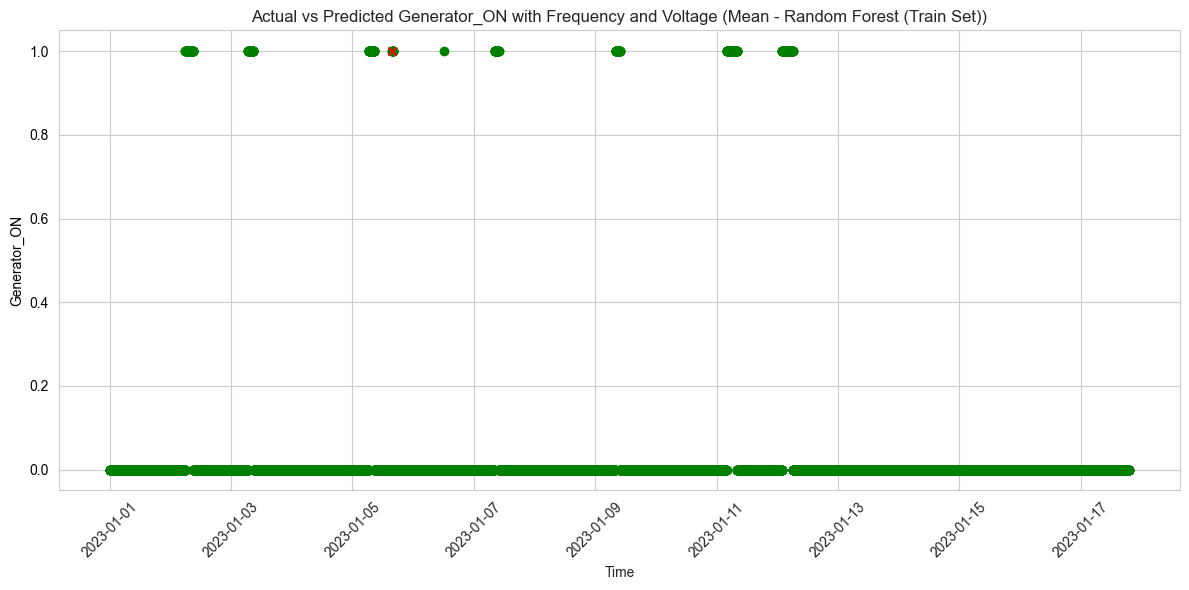

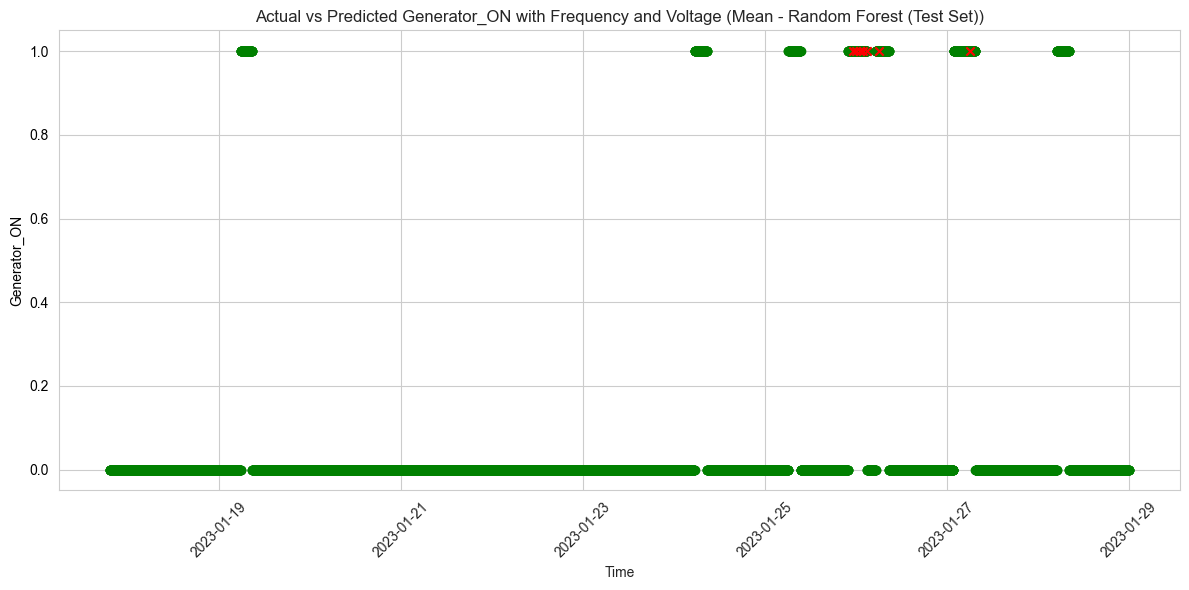

In [78]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_co_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_co_rf['prediction'].value_counts())
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_co_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_co_rf['prediction'].value_counts())

# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False,
                            include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_co_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False,
                            include_frequency=False)

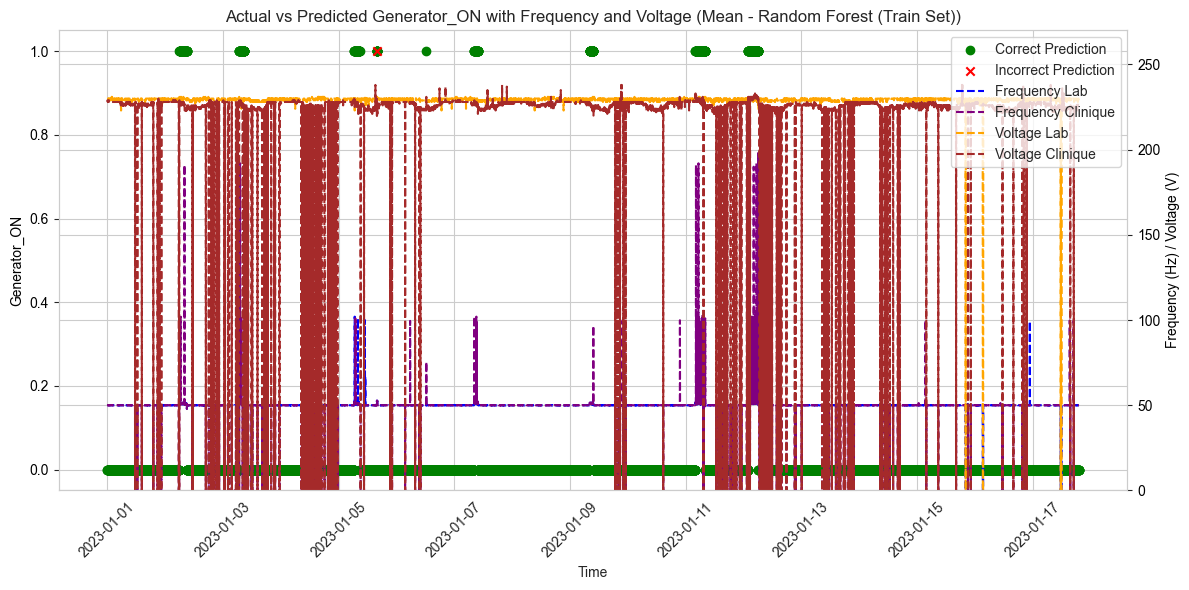

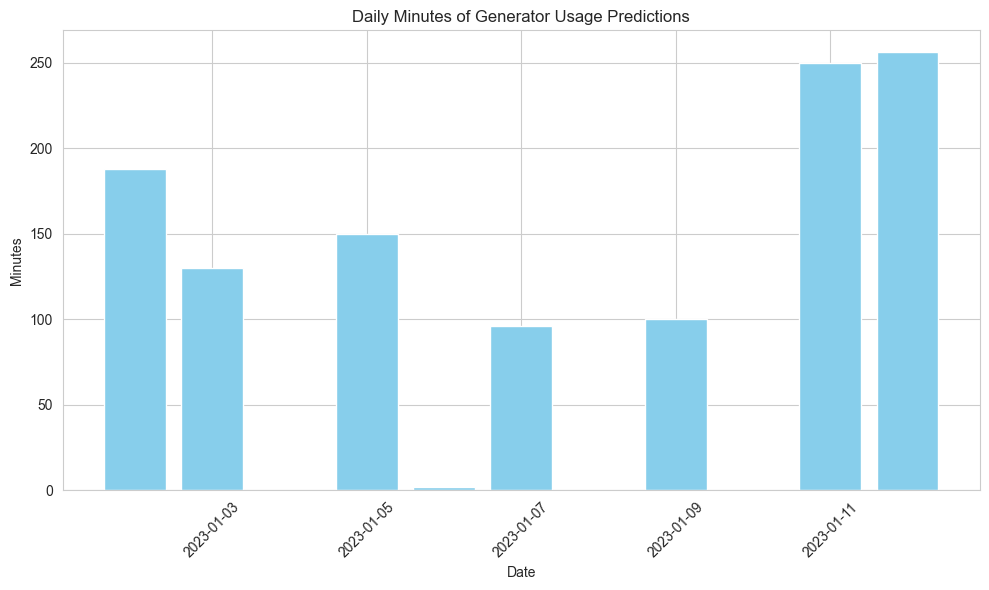

,Date,Count,Minutes,Hours
0,2023-01-02,94,188,3.133333
1,2023-01-03,65,130,2.166667
2,2023-01-05,75,150,2.500000
3,2023-01-06,1,2,0.033333
4,2023-01-07,48,96,1.600000
5,2023-01-09,50,100,1.666667
6,2023-01-11,125,250,4.166667
7,2023-01-12,128,256,4.266667


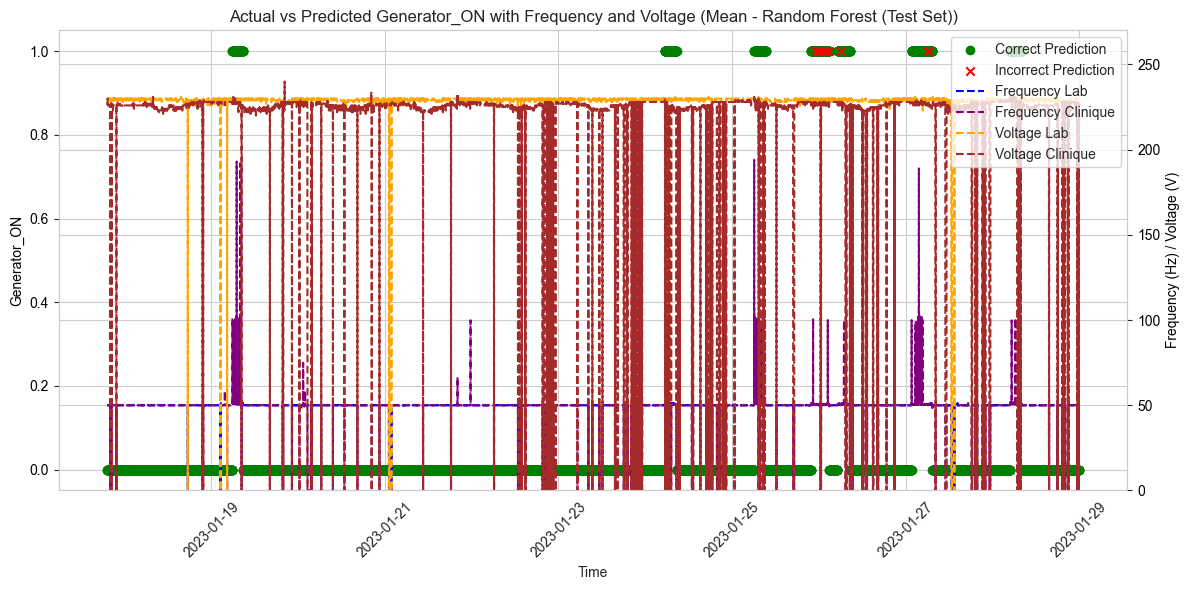

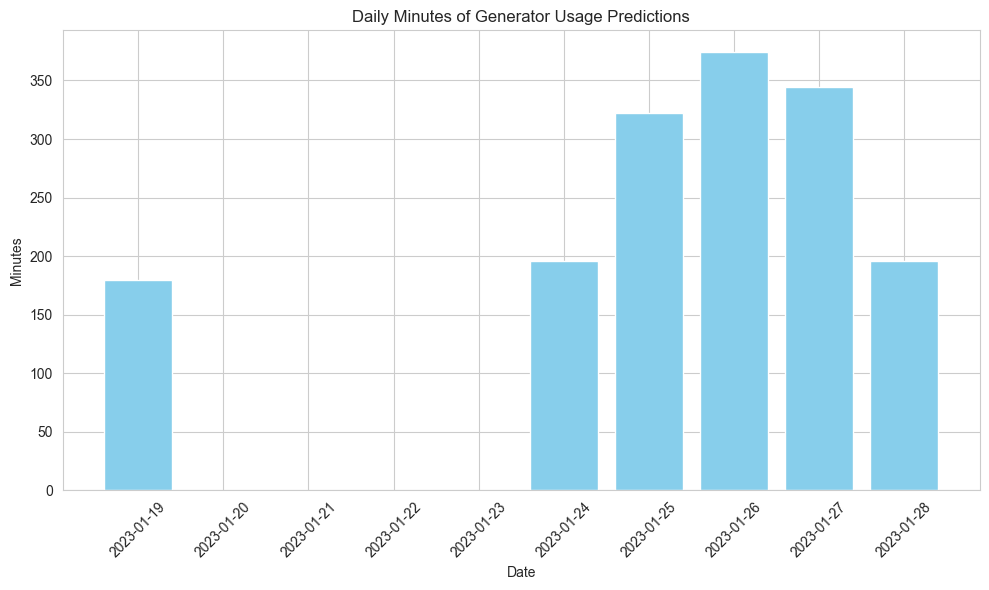

,Date,Count,Minutes,Hours
0,2023-01-19,90,180,3.000000
1,2023-01-24,98,196,3.266667
2,2023-01-25,161,322,5.366667
3,2023-01-26,187,374,6.233333
4,2023-01-27,172,344,5.733333
5,2023-01-28,98,196,3.266667


##### PREDICTION RESULT #####
Actual Minutes: 587 minutes, or 9.78 hours within 201.60 hours
Predicted Minutes: 586 minutes, or 9.77 hours within 201.60 hours
Actual Minutes: 814 minutes, or 13.57 hours within 134.40 hours
Predicted Minutes: 806 minutes, or 13.43 hours within 134.40 hours


In [79]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
train_data_ts_co_rf_daily_count = plot_true_predictions_histogram(train_data_ts_co_rf)
display(train_data_ts_co_rf_daily_count)

# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_co_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
test_data_ts_co_rf_daily_count = plot_true_predictions_histogram(test_data_ts_co_rf)
display(test_data_ts_co_rf_daily_count)
train_data_ts_co_rf['Generator_ON'].dtype

print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_rf)
display_generator_statistics(test_data_ts_co_rf)

#### 4.3.3. Adding the Correlation functions (HMM) - XGBoost

In [80]:
# Step 0: Copy rf data
train_data_ts_co_boost = train_data_ts_co.copy()
test_data_ts_co_boost = test_data_ts_co.copy()

# Step 1: Use the same data and feature columns (with copy to avoid SettingWithCopyWarning)
X_train = train_data_ts_co_boost[feature_columns].copy()
y_train = train_data_ts_co_boost['Generator_ON']

X_test = test_data_ts_co_boost.reindex(columns=feature_columns, fill_value=0).copy()
y_test = test_data_ts_co_boost['Generator_ON']

# Convert specific columns to numeric
cols_to_convert = [
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_train[cols_to_convert] = X_train[cols_to_convert].apply(pd.to_numeric, errors='coerce')
X_test[cols_to_convert] = X_test[cols_to_convert].apply(pd.to_numeric, errors='coerce')

#### This section is for XGBoost parameter search using cross validation

In [81]:
'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_co_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_co_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_co_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_co_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nf

In [82]:
# Use the best parameters from GridSearchCV - Saved so no need to re run the parameters. Only re run if we have additional features or different training data 

best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}


# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_co_boost['prediction'] = final_model.predict(X_train)
test_data_ts_co_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_co_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_co_boost['prediction']))

# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_co_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_co_boost['prediction'].value_counts())
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_co_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_co_boost['prediction'].value_counts())

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      7250
        True       1.00      0.99      1.00       814

    accuracy                           1.00      8064
   macro avg       1.00      1.00      1.00      8064
weighted avg       1.00      1.00      1.00      8064

AUC-ROC Score:
0.9999996611031094
Confusion Matrix:
[[7250    0]
 [   7  807]]
Train Set Evaluation (XGBoost):
Accuracy: 0.999917328042328
Confusion Matrix:
[[11509     0]
 [    1   586]]
Precision: 1.0
Recall: 0.9982964224872232
Train data prediction distribution (XGBoost):
prediction
0    11510
1      586
Name: count, dtype: int64

Test Set Evaluation (XGBoost):
Accuracy: 0.9991319444444444
Confusion Matrix:
[[7250    0]
 [   7  807]]
Precision: 1.0
Recall: 0.9914004914004914
Test data prediction distribution (XGBoost):
prediction
0    7257
1     807
Name: count, dtype: int64


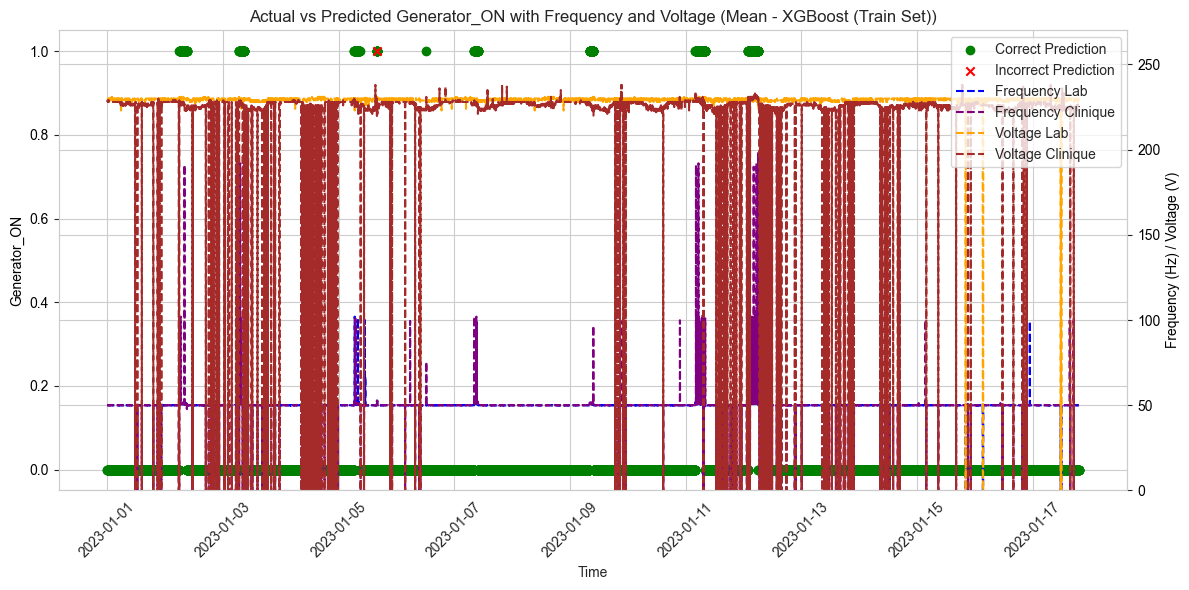

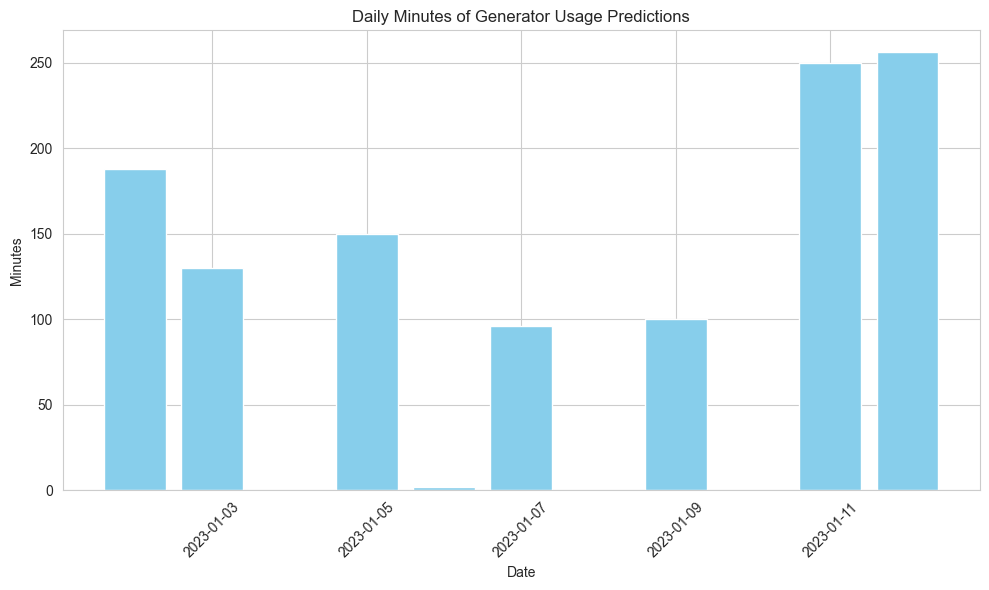

,Date,Count,Minutes,Hours
0,2023-01-02,94,188,3.133333
1,2023-01-03,65,130,2.166667
2,2023-01-05,75,150,2.500000
3,2023-01-06,1,2,0.033333
4,2023-01-07,48,96,1.600000
5,2023-01-09,50,100,1.666667
6,2023-01-11,125,250,4.166667
7,2023-01-12,128,256,4.266667


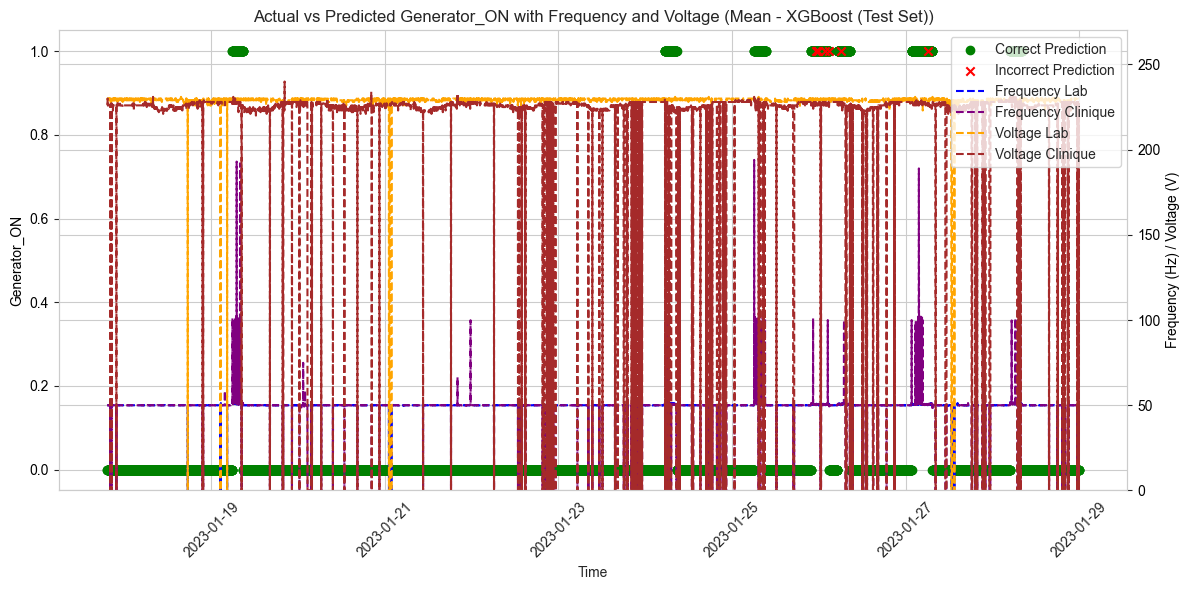

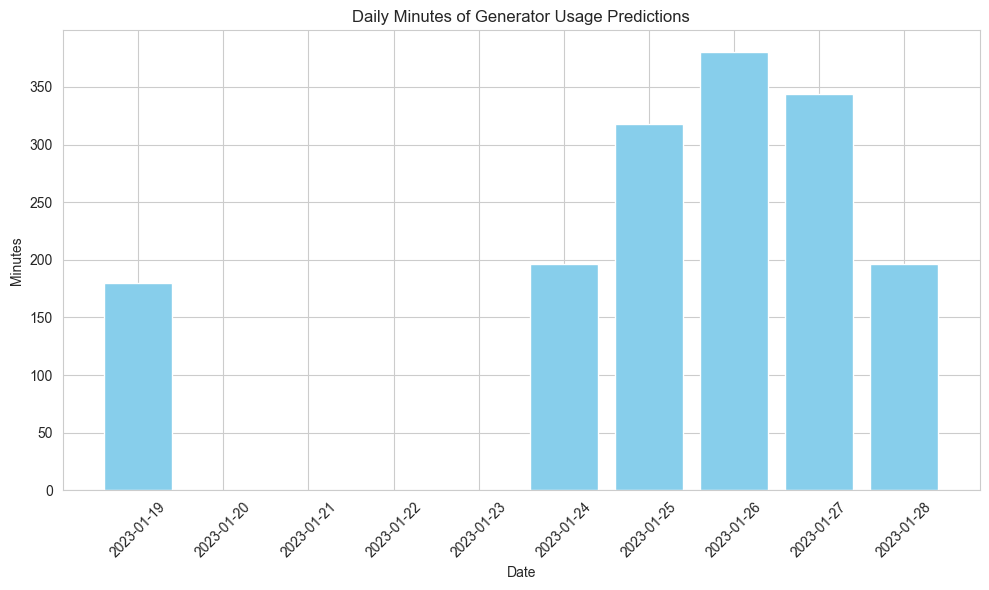

,Date,Count,Minutes,Hours
0,2023-01-19,90,180,3.000000
1,2023-01-24,98,196,3.266667
2,2023-01-25,159,318,5.300000
3,2023-01-26,190,380,6.333333
4,2023-01-27,172,344,5.733333
5,2023-01-28,98,196,3.266667


In [83]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_boost, model_name="Mean - XGBoost (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
train_data_ts_co_boost_daily_count = plot_true_predictions_histogram(train_data_ts_co_boost)
display(train_data_ts_co_boost_daily_count)

# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_co_boost, model_name="Mean - XGBoost (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
test_data_ts_co_boost_daily_count = plot_true_predictions_histogram(test_data_ts_co_boost)
display(test_data_ts_co_boost_daily_count)

In [84]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_boost)
display_generator_statistics(test_data_ts_co_boost)

##### PREDICTION RESULT #####
Actual Minutes: 587 minutes, or 9.78 hours within 201.60 hours
Predicted Minutes: 586 minutes, or 9.77 hours within 201.60 hours
Actual Minutes: 814 minutes, or 13.57 hours within 134.40 hours
Predicted Minutes: 807 minutes, or 13.45 hours within 134.40 hours


## 5. Applying the Model with Other Data

Top 15 features sorted by importance:


,Feature,Importance
0,Frequency 09B35150 (Hgr Walikale - Lab),3.122081e-01
1,Frequency 64B734C2 (Hgr Walikale - Cabane),2.476169e-01
5,higher_freq_clinique,1.997581e-01
4,higher_freq_lab,7.083140e-02
8,Freq_delta_lab,4.384928e-02
9,Freq_delta_clinique,4.166051e-02
3,Voltage 64B734C2 (Hgr Walikale - Cabane),1.611141e-02
45,High_delta_freq_clinique,1.517982e-02
12,freq_delta_negative_lab,1.109924e-02
13,freq_delta_negative_clinique,8.674138e-03


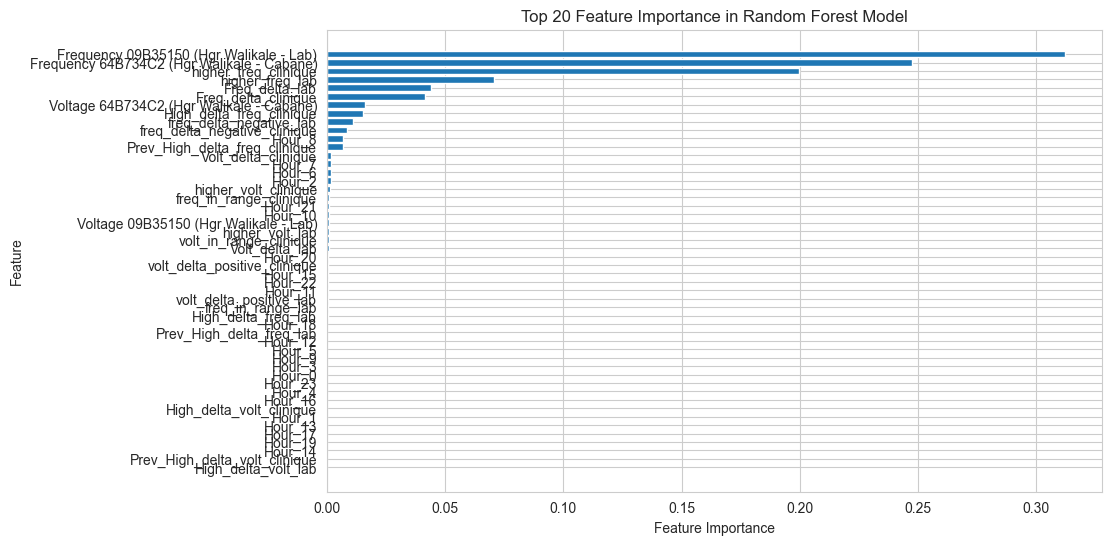

In [85]:
# Final Model use for prediction

# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

#### 5.1. Using 1 Month Data and Check the Prediction Result

In [86]:
# Opening files
file_list = ['Voltage Time Series-data-2024-10-25 13_13_06.csv',  
             'Voltage Time Series-data-2024-10-25 13_13_40.csv', 
             'Voltage Time Series-data-2024-10-25 13_14_12.csv',
             'Voltage Time Series-data-2024-10-25 13_14_37.csv',
             'Voltage Time Series-data-2024-10-25 13_18_07.csv']

# Initialize an empty list to collect DataFrames
data_frames_2 = []

file_path_2 = 'data/New 2/'

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path_2 + file)
    data_frames_2.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames_2, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

FileNotFoundError: [Errno 2] No such file or directory: 'data/New 2/Voltage Time Series-data-2024-10-25 13_13_06.csv'

In [ ]:
test_data_2

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2, test_data_2_dummy = calculate_mean_flags(data, data, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2, test_data_2_dummy = process_time_series_data(test_data_2, test_data_2, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
test_data_2_daily_count = plot_true_predictions_histogram(test_data_2)
test_data_2_daily_count

#### 5.2. Using 1 Year Data of Year 2023

Loading 1 year data into 1 dataframe:

In [ ]:
# Set the path to the folder containing CSV files
folder_path = 'data/2023 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2023 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2023['time'] = pd.to_datetime(data_2023['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2023 = data_2023.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2023

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2023, test_data_2023_dummy = calculate_mean_flags(data_2023, data_2023, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2023, test_data_2023_dummy = process_time_series_data(test_data_2023, test_data_2023, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2023)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2023[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2023['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

##### 5.2.1. Plot Result During Lost Clinique Data (2023)

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2023, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2023-12-01 00:00:00'
finished_date = '2023-12-31 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30
average_daily = filtered_test_data_2_daily_count['Minutes'].sum() / filtered_test_data_2_daily_count.shape[0] 
max_daily = filtered_test_data_2_daily_count['Minutes'].max()
# Find the row with the maximum 'Minutes' value
max_daily_row = filtered_test_data_2_daily_count.loc[filtered_test_data_2_daily_count['Minutes'].idxmax()]
# Extract the 'Date' column from that row
max_date = max_daily_row['Date']


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')
print(f'Average Daily Usage Minutes: {average_daily} minutes, or {average_daily / 60} hours')
print(f'Max minutes of usage {max_daily} minutes or {max_daily / 60} hours. Date: {max_date}')

##### 5.2.2. Plot Result First 10 days of July (2023)

In [ ]:
# Plot predictions based on certain timing choosen
start_date = '2023-02-14 00:00:00'
finished_date = '2023-02-17 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)

# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

#### 5.3. Using Data of Year 2022

Due to data limitations, only Data from 27th May 2022 - 31st December 2022 is available

In [ ]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/2022 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2022 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2022['time'] = pd.to_datetime(data_2022['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2022 = data_2022.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2022


In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2022, test_data_2022_dummy = calculate_mean_flags(data_2022, data_2022, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2022, test_data_2022_dummy = process_time_series_data(test_data_2022, test_data_2022, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2022)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2022[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2022['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2022['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2022) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

##### 5.2.2. Plot Result During Lost Clinique Data (2022)

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2022, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2022-06-20 00:00:00'
finished_date = '2022-06-30 23:59:59'
filtered_test_data_2022 = test_data_2022[(test_data_2022['Time'] >= start_date) & (test_data_2022['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2022,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2022)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2022['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2022) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

#### 5.4. Using Data of Year 2024

In [ ]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/2024 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2024 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2024['time'] = pd.to_datetime(data_2024['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2024 = data_2024.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2024

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2024, test_data_2024_dummy = calculate_mean_flags(data_2024, data_2024, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2024, test_data_2024_dummy = process_time_series_data(test_data_2024, test_data_2024, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2024)

# Define the feature columns
feature_columns = [
    freq_a,
    freq_b,
    volt_a,
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2024[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2024['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2024['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2024) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2024, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2024-10-11 00:00:00'
finished_date = '2024-10-20 23:59:59'
filtered_test_data_2024 = test_data_2024[(test_data_2024['Time'] >= start_date) & (test_data_2024['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2024,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2024)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2024['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2024) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

In [ ]:
## CHECK : 4-11 November

## 6. Summary of Data

#### 6.1. Generator 2022 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 6.2. Generator 2023 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 6.3. Generator 2024 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

## 7. Generator Power Calculation

In [ ]:
# Constant Declaration of Hourly kwh average
kwh_hour = [
    6.747835296, 7.057838155, 8.16854183, 11.30196556, 11.21547191, 9.88189269, 11.22740354, 12.85224141, 14.05086424, 13.96076821,
    13.70200973, 13.46483643, 13.25040271, 12.23739568, 9.853452467, 11.13546578, 11.58039839, 9.594331892, 9.649361468,
    8.320364238, 6.779637969, 6.241952539, 6.125157442, 6.18646468
]

#### 7.1. Generator 2022 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2022['power (kW)'] = test_data_2022.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2022[test_data_2022['prediction']]

In [ ]:
# Year 2022 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 7.2. Generator 2023 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2023['power (kW)'] = test_data_2023.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2023[test_data_2023['prediction']]

In [ ]:
# Year 2023 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 7.3. Generator 2024 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2024['power (kW)'] = test_data_2024.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2024[test_data_2024['prediction']]

In [ ]:
# Year 2024 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

## 8. Generator Emission Calculation

In [ ]:
# Constant Declaration of Emission index

#Assuming Un-Controlled NOx
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

kwh_to_hp_hr = 1.341
lb_to_gr = 453.592

#### 8.1. Generator 2022 Emission

In [ ]:
test_data_2022 = calculate_emissions(test_data_2022)

test_data_2022[test_data_2022['prediction']]

In [ ]:
generator_emission_summary(test_data_2022)

#### 8.2. Generator 2023 Emission

In [ ]:
test_data_2023 = calculate_emissions(test_data_2023)

test_data_2023[test_data_2023['prediction']]

In [ ]:
generator_emission_summary(test_data_2023)

#### 8.3. Generator 2024 Emission

In [ ]:
test_data_2024 = calculate_emissions(test_data_2024)

test_data_2024[test_data_2024['prediction']]

In [ ]:
generator_emission_summary(test_data_2024)

## 9. Generator Output Emissions File

In [ ]:
file_name = ["data_2022.csv", "data_2023.csv", "data_2024.csv"]
years = [2022, 2023, 2024]
columns = ['Time','prediction','power (kW)','NOx Emission (g)','CO Emission (g)','SOx Emission (g)','CO2 Emission (g)','PM Emission (g)', 'Date', 'Month']

test_data_2024[columns].to_csv('results/data_2024.csv', index = False)
test_data_2023[columns].to_csv('results/data_2023.csv', index = False)
test_data_2022[columns].to_csv('results/data_2022.csv', index = False)